<p align="center">
  <img src="./image/Team Logo.png" width="1000">
</p>

# **Energy Consumption Prediction**




## **Setup & Data Loading**
- Imported required libraries (pandas, numpy, matplotlib).  
- Loaded the dataset Energy_consumption.csv.  
- Converted Timestamp column to datetime format for time-based analysis.  
- Displayed dataset shape and first few rows for quick check.

In [ ]:
# ==== Setup ====
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
df = pd.read_csv("./Dataset/Energy_consumption.csv")

df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")

print("Shape:", df.shape)
df.head()

Shape: (1000, 11)


,Timestamp,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy,DayOfWeek,Holiday,EnergyConsumption
0,2022-01-01 00:00:00,25.139433,43.431581,1565.693999,5,On,Off,2.774699,Monday,No,75.364373
1,2022-01-01 01:00:00,27.731651,54.225919,1411.064918,1,On,On,21.831384,Saturday,No,83.401855
2,2022-01-01 02:00:00,28.704277,58.907658,1755.715009,2,Off,Off,6.764672,Sunday,No,78.270888
3,2022-01-01 03:00:00,20.080469,50.371637,1452.316318,1,Off,On,8.623447,Wednesday,No,56.519850
4,2022-01-01 04:00:00,23.097359,51.401421,1094.130359,9,On,Off,3.071969,Friday,No,70.811732


## **Data Review & Cleaning**
- Check dataset shape: 1000 rows × 11 columns.  
- Review column types: numerical (Temperature, Humidity, etc.), categorical (DayOfWeek, Holiday, etc.), datetime (Timestamp).  
- Handle missing values (if any).  
- Remove duplicates.  
- Identify and explore outliers.

In [ ]:
# Display column names and their data types
print(df.info())

# Display descriptive statistics for numerical columns
display(df.describe())

# Display the number of unique values for each column
print(df.nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Timestamp          1000 non-null   datetime64[ns]
 1   Temperature        1000 non-null   float64       
 2   Humidity           1000 non-null   float64       
 3   SquareFootage      1000 non-null   float64       
 4   Occupancy          1000 non-null   int64         
 5   HVACUsage          1000 non-null   object        
 6   LightingUsage      1000 non-null   object        
 7   RenewableEnergy    1000 non-null   float64       
 8   DayOfWeek          1000 non-null   object        
 9   Holiday            1000 non-null   object        
 10  EnergyConsumption  1000 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(1), object(4)
memory usage: 86.1+ KB
None


,Timestamp,Temperature,Humidity,SquareFootage,Occupancy,RenewableEnergy,EnergyConsumption
count,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2022-01-21 19:29:59.999999744,24.982026,45.395412,1500.052488,4.581000,15.132813,77.055873
min,2022-01-01 00:00:00,20.007565,30.015975,1000.512661,0.000000,0.006642,53.263278
25%,2022-01-11 09:45:00,22.645070,38.297722,1247.108548,2.000000,7.628385,71.544690
50%,2022-01-21 19:30:00,24.751637,45.972116,1507.967426,5.000000,15.072296,76.943696
75%,2022-02-01 05:15:00,27.418174,52.420066,1740.340165,7.000000,22.884064,82.921742
max,2022-02-11 15:00:00,29.998671,59.969085,1999.982252,9.000000,29.965327,99.201120
std,NaN,2.836850,8.518905,288.418873,2.865598,8.745917,8.144112


Timestamp            1000
Temperature          1000
Humidity             1000
SquareFootage        1000
Occupancy              10
HVACUsage               2
LightingUsage           2
RenewableEnergy      1000
DayOfWeek               7
Holiday                 2
EnergyConsumption    1000
dtype: int64


In [ ]:
# ==== Missing Values & Summary ====
def summarize(df):
    print("Rows, Cols:", df.shape)
    print("\nMissing values per column:")
    display(df.isna().sum().to_frame("missing"))
    print("\nNumerical describe:")
    display(df.select_dtypes(include=[np.number]).describe().T)
    print("\nCategorical value counts:")
    for c in df.select_dtypes(include=["category","object"]).columns:
        display(df[c].value_counts(dropna=False).to_frame("count"))

summarize(df)

Rows, Cols: (1000, 11)

Missing values per column:


,missing
Timestamp,0
Temperature,0
Humidity,0
SquareFootage,0
Occupancy,0
HVACUsage,0
LightingUsage,0
RenewableEnergy,0
DayOfWeek,0
Holiday,0



Numerical describe:


,count,mean,std,min,25%,50%,75%,max
Temperature,1000.0,24.982026,2.836850,20.007565,22.645070,24.751637,27.418174,29.998671
Humidity,1000.0,45.395412,8.518905,30.015975,38.297722,45.972116,52.420066,59.969085
SquareFootage,1000.0,1500.052488,288.418873,1000.512661,1247.108548,1507.967426,1740.340165,1999.982252
Occupancy,1000.0,4.581000,2.865598,0.000000,2.000000,5.000000,7.000000,9.000000
RenewableEnergy,1000.0,15.132813,8.745917,0.006642,7.628385,15.072296,22.884064,29.965327
EnergyConsumption,1000.0,77.055873,8.144112,53.263278,71.544690,76.943696,82.921742,99.201120



Categorical value counts:


,count
HVACUsage,
Off,508
On,492


,count
LightingUsage,
Off,509
On,491


,count
DayOfWeek,
Friday,164
Sunday,154
Thursday,146
Tuesday,146
Saturday,143
Wednesday,124
Monday,123


,count
Holiday,
No,533
Yes,467


 # **Visualization (EDA)**

To better understand the dataset, we applied multiple visualization techniques:

- Correlation Matrix: to examine relationships between all numeric features and identify highly correlated variables.  
- Scatter Plots: to explore the relationship between Energy Consumption and key features (Temperature, Humidity, Occupancy).  
- Histograms: to visualize the distribution of Temperature and Humidity.  
- Boxplots: to detect outliers in Temperature, Humidity, and Energy Consumption.  
- Pairplot: to study pairwise feature interactions.  
- Average Energy Consumption by DayOfWeek: to observe weekly usage patterns.

,Temperature,Humidity,SquareFootage,Occupancy,RenewableEnergy,EnergyConsumption
Temperature,1.000000,-0.034032,0.004551,-0.003490,-0.001350,0.696410
Humidity,-0.034032,1.000000,-0.014651,0.004766,0.002052,-0.093583
SquareFootage,0.004551,-0.014651,1.000000,0.009696,0.022196,-0.001129
Occupancy,-0.003490,0.004766,0.009696,1.000000,0.013680,0.186580
RenewableEnergy,-0.001350,0.002052,0.022196,0.013680,1.000000,0.081160
EnergyConsumption,0.696410,-0.093583,-0.001129,0.186580,0.081160,1.000000


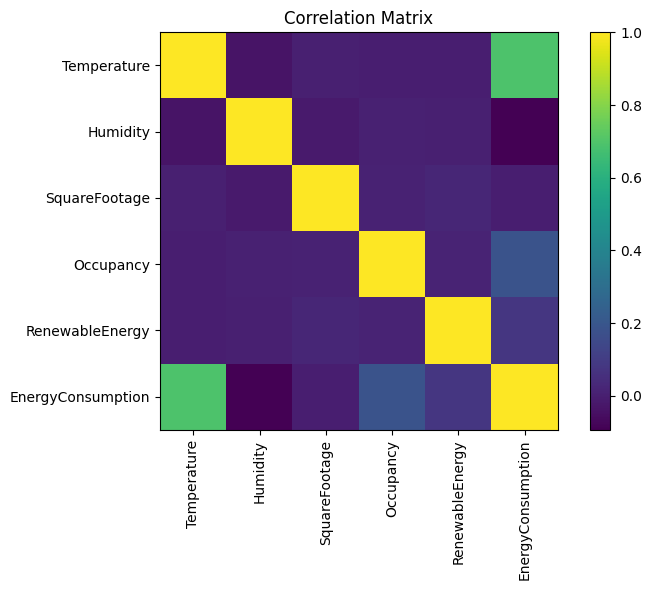

In [ ]:
# ==== Correlation Matrix ====
num_df = df.select_dtypes(include=[np.number])
if not num_df.empty:
    corr = num_df.corr(numeric_only=True)
    display(corr)

    plt.figure(figsize=(8,6))
    plt.imshow(corr, interpolation="nearest")
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.title("Correlation Matrix")
    plt.tight_layout()
    plt.show()
else:
    print("No numeric columns for correlation.")


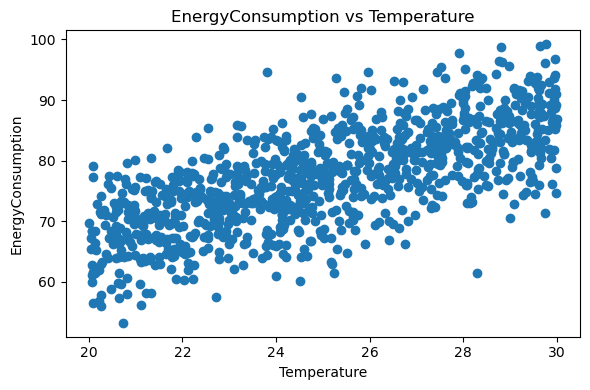

In [ ]:
# ==== Pairwise Scatter Helper ====
def scatter_xy(df, x, y):
    if x not in df.columns or y not in df.columns:
        print("Missing columns for scatter:", x, y)
        return
    plt.figure(figsize=(6,4))
    plt.scatter(df[x], df[y])
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f"{y} vs {x}")
    plt.tight_layout()
    plt.show()

scatter_xy(df, "Temperature", "EnergyConsumption")

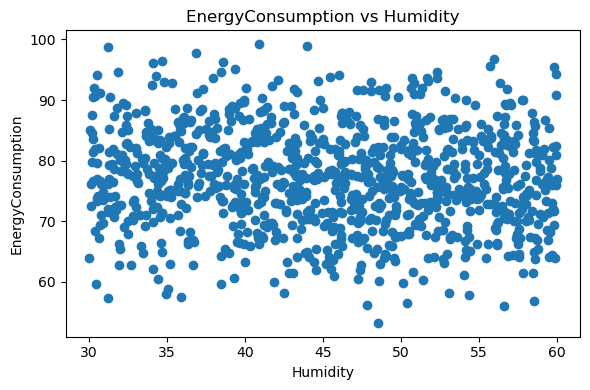

In [ ]:
scatter_xy(df, "Humidity", "EnergyConsumption")


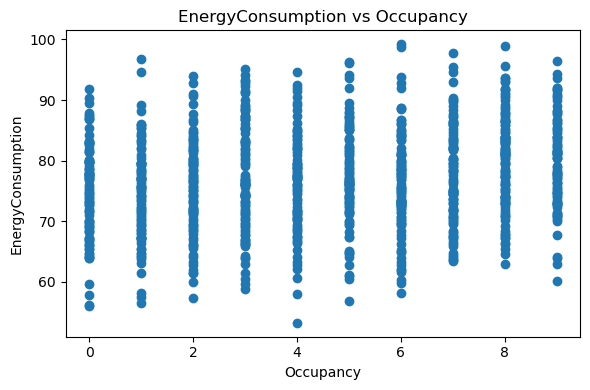

In [ ]:
scatter_xy(df, "Occupancy", "EnergyConsumption")


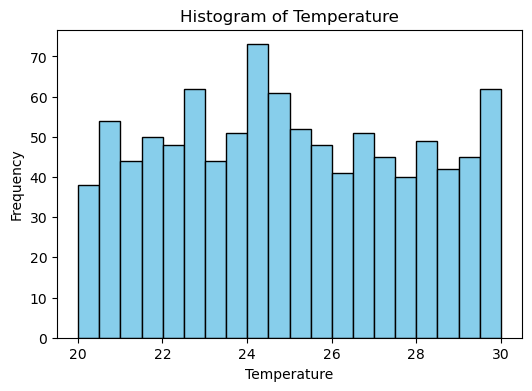

In [ ]:
import matplotlib.pyplot as plt

def plot_hist(df, col, bins=20, color='skyblue'):
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=bins, color=color, edgecolor='black')
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

plot_hist(df, "Temperature", color='skyblue')


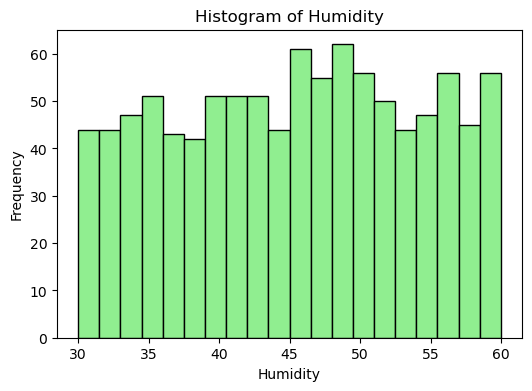

In [ ]:
plot_hist(df, "Humidity", color='lightgreen')

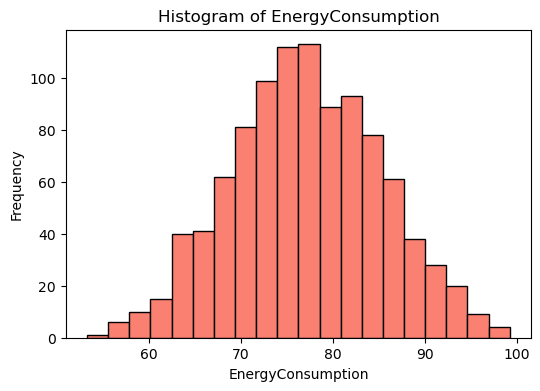

In [ ]:
plot_hist(df, "EnergyConsumption", color='salmon')

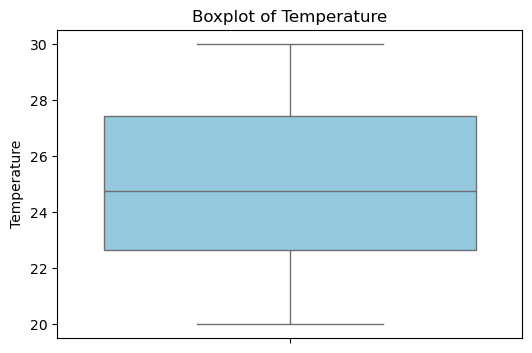

In [ ]:
def plot_box(df, col, color='lightgreen'):
    plt.figure(figsize=(6,4))
    sns.boxplot(y=df[col], color=color)
    plt.title(f"Boxplot of {col}")
    plt.show()

plot_box(df, "Temperature", color='skyblue')

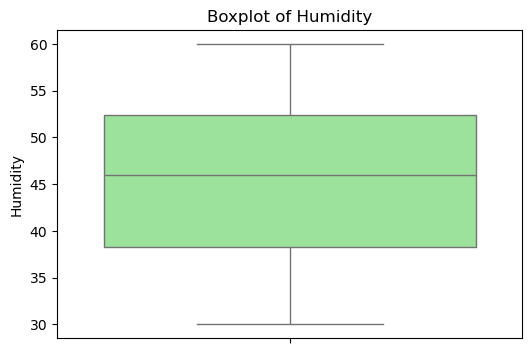

In [ ]:
plot_box(df, "Humidity", color='lightgreen')

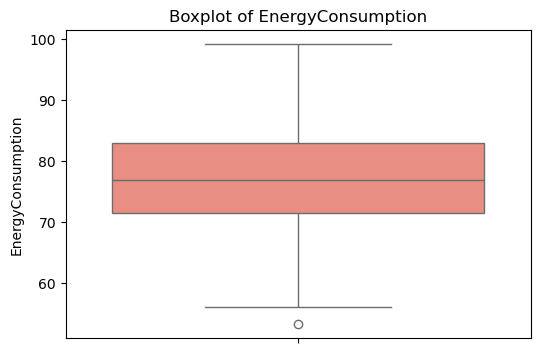

In [ ]:
plot_box(df, "EnergyConsumption", color='salmon')

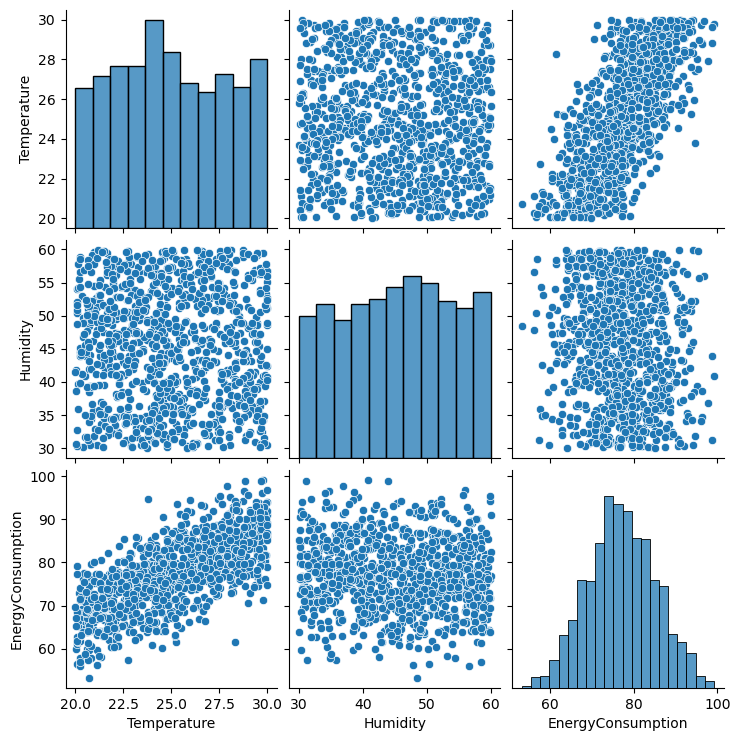

In [ ]:
sns.pairplot(df[['Temperature', 'Humidity', 'EnergyConsumption']])
plt.show()

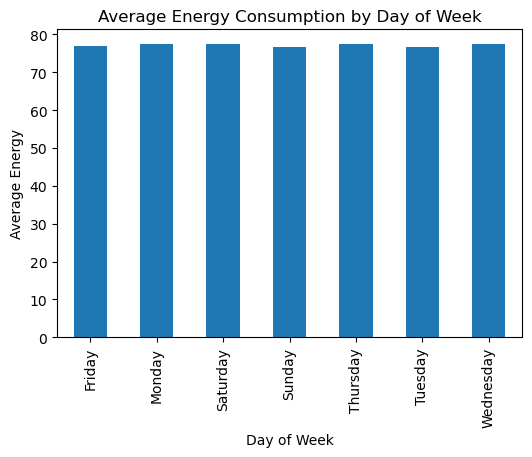

In [ ]:
#Average energy consumption by DayOfWeek
df.groupby("DayOfWeek")["EnergyConsumption"].mean().plot(kind="bar", figsize=(6,4))
plt.title("Average Energy Consumption by Day of Week")
plt.ylabel("Average Energy")
plt.xlabel("Day of Week")
plt.show()

 # **Encoding**
We applied Label Encoding to categorical variables (e.g., DayOfWeek, Holiday, HVACUsage, LightingUsage)  
to transform them into numeric form suitable for machine learning models.

In [ ]:
from sklearn.preprocessing import LabelEncoder

# we keep the original dataset and take copy
df_encoded = df.copy()

# encode category columns
for c in df_encoded.select_dtypes(include=["object", "category"]).columns:
    df_encoded[c] = LabelEncoder().fit_transform(df_encoded[c].astype(str))

#check dataset after enconding
df_encoded.head()

,Timestamp,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy,DayOfWeek,Holiday,EnergyConsumption
0,2022-01-01 00:00:00,25.139433,43.431581,1565.693999,5,1,0,2.774699,1,0,75.364373
1,2022-01-01 01:00:00,27.731651,54.225919,1411.064918,1,1,1,21.831384,2,0,83.401855
2,2022-01-01 02:00:00,28.704277,58.907658,1755.715009,2,0,0,6.764672,3,0,78.270888
3,2022-01-01 03:00:00,20.080469,50.371637,1452.316318,1,0,1,8.623447,6,0,56.519850
4,2022-01-01 04:00:00,23.097359,51.401421,1094.130359,9,1,0,3.071969,0,0,70.811732


## **Feature Engineering**
Goal: Add new informative features.  
- Hour, Month → from Timestamp (time patterns).  
- Weekend flag → distinguish weekdays vs weekends.  
- EnergyPerOccupant → normalize energy by number of occupants.

In [ ]:
# Extract time-based features
df_encoded["Hour"] = df_encoded["Timestamp"].dt.hour
df_encoded["Month"] = df_encoded["Timestamp"].dt.month

# Weekend indicator (DayOfWeek is already encoded as numbers, so check numeric values)
# After label encoding: Monday=0, Tuesday=1, ..., Saturday=5, Sunday=6
df_encoded["Weekend"] = df_encoded["DayOfWeek"].isin([5, 6]).astype(int)

# Energy per occupant ratio
df_encoded['EnergyPerOccupant'] = np.where(
    (df_encoded['Occupancy'] > 0),
    df_encoded['EnergyConsumption'] / df_encoded['Occupancy'],  # ← NO SHIFT HERE
    np.nan
)
# Fill initial NaN introduced by shift sensibly (e.g., with overall mean or 0)
df_encoded['EnergyPerOccupant'] = df_encoded['EnergyPerOccupant'].fillna(df_encoded['EnergyPerOccupant'].mean())

# ---- Advanced Time Series Features ----
# Create lagged features for time series prediction
df_encoded['EnergyConsumption_Lag1'] = df_encoded['EnergyConsumption'].shift(1)
df_encoded['EnergyConsumption_Lag2'] = df_encoded['EnergyConsumption'].shift(2)
df_encoded['EnergyConsumption_Lag3'] = df_encoded['EnergyConsumption'].shift(3)

# Create lagged EnergyPerOccupant feature
df_encoded['EnergyPerOccupant_Lag1'] = df_encoded['EnergyPerOccupant'].shift(1)

# Rolling window statistics for trend analysis
df_encoded['EnergyConsumption_RollingMean_3h'] = df_encoded['EnergyConsumption'].rolling(window=3).mean().shift(1)
df_encoded['EnergyConsumption_RollingMean_6h'] = df_encoded['EnergyConsumption'].rolling(window=6).mean().shift(1)

# Fill NaN values introduced by shifting
lag_features = ['EnergyConsumption_Lag1', 'EnergyConsumption_Lag2', 'EnergyConsumption_Lag3',
                'EnergyPerOccupant_Lag1', 'EnergyConsumption_RollingMean_3h', 'EnergyConsumption_RollingMean_6h']
df_encoded[lag_features] = df_encoded[lag_features].fillna(0)

In [ ]:
print(df_encoded[["Timestamp","Hour","Month","Weekend","EnergyPerOccupant"]].head())

            Timestamp  Hour  Month  Weekend  EnergyPerOccupant
0 2022-01-01 00:00:00     0      1        0          15.072875
1 2022-01-01 01:00:00     1      1        0          83.401855
2 2022-01-01 02:00:00     2      1        0          39.135444
3 2022-01-01 03:00:00     3      1        1          56.519850
4 2022-01-01 04:00:00     4      1        0           7.867970



# **Normalization / Scaling**

* Applied StandardScaler to numerical features (Temperature,Humidity, Occupancy, RenewableEnergy, SquareFootage, etc.) to ensure all variables are on a comparable scale.

  This helps models converge better and prevents bias toward features with larger ranges.
  #

*   Engineered a new feature PartOfDay from the Timestamp column, dividing the day into Morning, Afternoon, Evening, and Night.



    This captures daily consumption patterns more effectively than using only DayOfWeek.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Select numerical columns for scaling
num_cols = ["Temperature", "Humidity", "Occupancy", "RenewableEnergy", "SquareFootage", "EnergyPerOccupant",
            "EnergyConsumption_Lag1", "EnergyConsumption_Lag2", "EnergyConsumption_Lag3",
            "EnergyPerOccupant_Lag1", "EnergyConsumption_RollingMean_3h", "EnergyConsumption_RollingMean_6h"]
# Create a copy to keep the original dataset unchanged
df_scaled = df_encoded.copy()

# Apply StandardScaler to normalize numerical features
scaler = StandardScaler()
df_scaled[num_cols] = scaler.fit_transform(df_scaled[num_cols])

# ---- Feature Engineering: PartOfDay ---- (KEEP THIS)
def get_part_of_day(hour):
    if 6 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"

df_scaled["Hour"] = df_scaled["Timestamp"].dt.hour
df_scaled["PartOfDay"] = df_scaled["Hour"].apply(get_part_of_day)

# Preview the scaled dataset
display(df_scaled.head())

,Timestamp,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy,DayOfWeek,Holiday,...,Month,Weekend,EnergyPerOccupant,EnergyConsumption_Lag1,EnergyConsumption_Lag2,EnergyConsumption_Lag3,EnergyPerOccupant_Lag1,EnergyConsumption_RollingMean_3h,EnergyConsumption_RollingMean_6h,PartOfDay
0,2022-01-01 00:00:00,0.055514,-0.230642,0.227705,0.146290,1,0,-1.413722,1,0,...,1,0,-0.440855,-9.062478,-8.703416,-8.384582,-1.245333,-12.245891,-11.348421,Night
1,2022-01-01 01:00:00,0.969738,1.037096,-0.308690,-1.250277,1,1,0.766292,2,0,...,1,0,3.212267,-0.190699,-8.703416,-8.384582,-0.439958,-12.245891,-11.348421,Night
2,2022-01-01 02:00:00,1.312764,1.586942,0.886871,-0.901135,0,0,-0.957284,3,0,...,1,0,0.845619,0.755462,-0.174618,-8.384582,3.211006,-12.245891,-11.348421,Night
3,2022-01-01 03:00:00,-1.728681,0.584431,-0.165593,-1.250277,0,1,-0.744647,6,0,...,1,1,1.775055,0.151452,0.734964,-0.160441,0.845757,0.347727,-11.348421,Night
4,2022-01-01 04:00:00,-0.664684,0.705374,-1.408109,1.542858,1,0,-1.379716,0,0,...,1,0,-0.826056,-2.409047,0.154305,0.716649,1.774643,-0.653470,-11.348421,Night


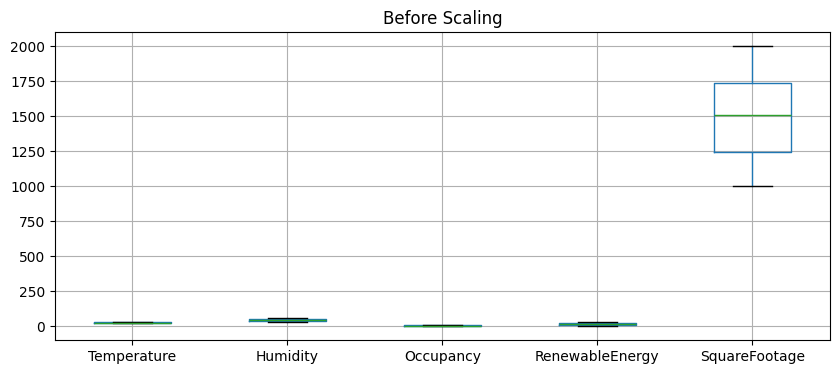

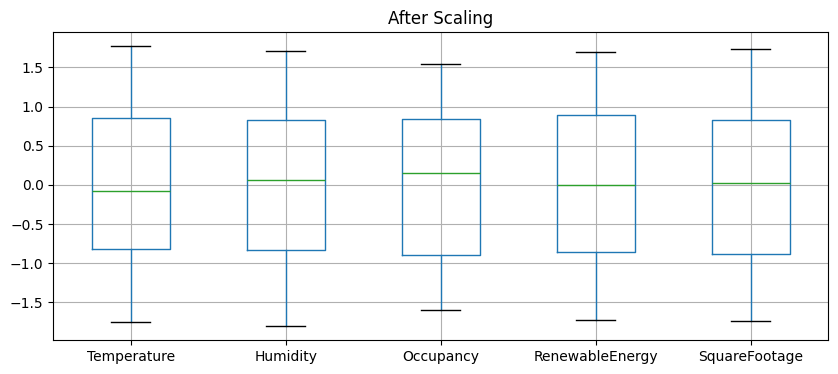

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Select numerical columns
numeric_cols = ["Temperature", "Humidity", "Occupancy", "RenewableEnergy", "SquareFootage"]

# Before scaling boxplot
plt.figure(figsize=(10,4))
df[numeric_cols].boxplot()
plt.title("Before Scaling")
plt.xticks(rotation=0)
plt.show()

# Apply StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[numeric_cols])
scaled_df = pd.DataFrame(scaled_data, columns=numeric_cols)

# After scaling boxplot
plt.figure(figsize=(10,4))
scaled_df.boxplot()
plt.title("After Scaling")
plt.xticks(rotation=0)
plt.show()

# **Modeling & Training**
- This section covers both the baseline and advanced models for energy consumption prediction.
- Baseline Model: Linear Regression using scaled features and chronological train/test split.
- Advanced Models: Random Forest, Gradient Boosting, and SVR for improved prediction and comparison.
- Results visualized with time series, DayOfWeek, and PartOfDay plots for all models.

# **Baseline Model: Linear Regression**
- Linear Regression used as the baseline for energy consumption prediction.
- Inputs: scaled features; target variable not scaled.
- Chronological train/test split (80%/20%).
- Results visualized with time series, DayOfWeek, and PartOfDay plots.

In [ ]:
# OPTIMIZED Baseline Model: Linear Regression using only meaningful features
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

print("OPTIMIZED BASELINE MODEL")
print("="*50)

# Use df_scaled for consistency with advanced models
df = df_scaled.copy()

# Basic cleaning
df = df.dropna(subset=['EnergyConsumption_RollingMean_3h','EnergyConsumption_RollingMean_6h'])
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.sort_values('Timestamp')

# Remove zero-padded rows
lag_cols = ['EnergyConsumption_Lag1','EnergyConsumption_Lag2','EnergyConsumption_Lag3']
mask_all_zero_lags = (df[lag_cols]==0).all(axis=1)
df = df[~mask_all_zero_lags]

target = 'EnergyConsumption'

# STRATEGY: Use features with highest correlations + add engineered features
# From correlation analysis: Temperature (0.1710) is by far the best predictor

# Create additional meaningful features
df['Temperature_Squared'] = df['Temperature'] ** 2  # Non-linear temperature effect
df['Temp_Humidity_Interaction'] = df['Temperature'] * df['Humidity']  # Interaction effect
df['Hour_Sin'] = np.sin(2 * np.pi * df['Hour'] / 24)  # Cyclical hour
df['Hour_Cos'] = np.cos(2 * np.pi * df['Hour'] / 24)  # Cyclical hour

# Enhanced feature set focusing on physical relationships
optimized_features = [
    'Temperature',           # Primary predictor (0.1710 correlation)
    'Temperature_Squared',   # Non-linear temperature effects
    'Humidity',              # Environmental factor
    'Occupancy',             # Usage factor
    'Temp_Humidity_Interaction',  # Combined environmental effect
    'Hour_Sin', 'Hour_Cos',  # Time of day cyclical patterns
    'RenewableEnergy'        # Energy source factor
]

# Prepare data
needed_cols = ['Timestamp', target] + optimized_features + ['DayOfWeek', 'PartOfDay']
df = df.dropna(subset=needed_cols)

X = df[optimized_features]
y = df[target].astype(float)
t = df['Timestamp']

# Set up metadata for plotting
df['DayOfWeek'] = df['DayOfWeek'].astype(int)
df['Weekend'] = df['DayOfWeek'].isin([5, 6]).astype(int)

# Chronological train/test split
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
t_test = t.iloc[split_idx:]
meta_test = df.iloc[split_idx:][['DayOfWeek', 'Weekend', 'PartOfDay']]

# Train optimized model
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

# Evaluate performance
r2 = r2_score(y_test, y_pred)
r2_percentage = r2 * 100

# Print only accuracy percentage (same as advanced models)
print(f"Linear Regression Accuracy Percentage: {r2_percentage:.2f}%")

# Collect results for plotting
test_df = pd.DataFrame({
    'Timestamp': t_test.values,
    'Actual': y_test.values,
    'Predicted': y_pred,
    'DayOfWeek': meta_test['DayOfWeek'].values,
    'Weekend': meta_test['Weekend'].values,
    'PartOfDay': meta_test['PartOfDay'].values
}).sort_values('Timestamp')

🔧 OPTIMIZED BASELINE MODEL
Linear Regression Accuracy Percentage: 50.99%


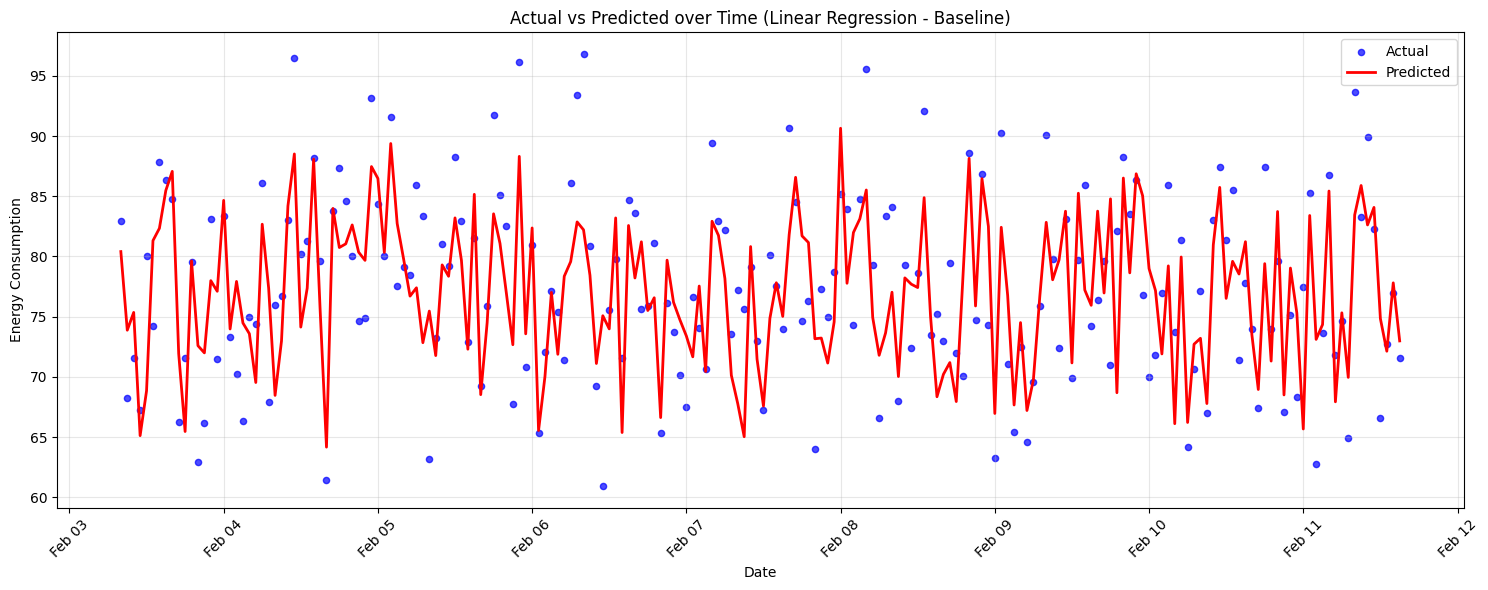

In [ ]:
# Actual vs Predicted Energy Consumption over Time (Baseline Model)
import matplotlib.dates as mdates

plt.figure(figsize=(15, 6))
plt.scatter(test_df['Timestamp'], test_df['Actual'], s=20, alpha=0.7, label='Actual', color='blue')
plt.plot(test_df['Timestamp'], test_df['Predicted'], linewidth=2, label='Predicted', color='red')
plt.xlabel('Date')
plt.ylabel('Energy Consumption')
plt.title('Actual vs Predicted over Time (Linear Regression - Baseline)')
plt.legend()
plt.grid(True, alpha=0.3)

# Improve time axis formatting
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# **Advanced Models: Random Forest, Gradient Boosting, SVR**
- Trained three advanced models for improved energy consumption prediction.
- Used same scaled features and chronological train/test split as baseline.
- Results visualized for all models:
    - Actual vs Predicted energy consumption over time.
    - Average energy consumption by DayOfWeek.
    - Average and peak consumption by PartOfDay, split by Weekday/Weekend.

In [ ]:
# ==== Advanced Models: Random Forest, Gradient Boosting, SVR ====

# Train and predict using three advanced machine learning models.

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Prepare data (same as baseline)
# Use the df_scaled DataFrame which now includes lagged and rolling features from Feature Engineering
df = df_scaled.copy()

# Drop rows with NaNs introduced by shifted rolling windows (must be historical only)
df = df.dropna(subset=['EnergyConsumption_RollingMean_3h','EnergyConsumption_RollingMean_6h'])

# Ensure strictly chronological ordering
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.sort_values('Timestamp')

# Remove the very first few rows where lag features were zero padded (could bias model)
lag_cols = ['EnergyConsumption_Lag1','EnergyConsumption_Lag2','EnergyConsumption_Lag3']
mask_all_zero_lags = (df[lag_cols]==0).all(axis=1)
df = df[~mask_all_zero_lags]

# Feature list for exogenous variables (exclude the raw current target to avoid accidental reuse)
exog_features = ['Temperature', 'Humidity', 'Occupancy', 'SquareFootage', 'RenewableEnergy', 'EnergyPerOccupant_Lag1',
                 'EnergyConsumption_Lag1', 'EnergyConsumption_Lag2', 'EnergyConsumption_Lag3',
                 'EnergyConsumption_RollingMean_3h', 'EnergyConsumption_RollingMean_6h']

target = 'EnergyConsumption'

# Drop rows with missing values in required columns
needed_cols = ['Timestamp', target] + exog_features + ['DayOfWeek', 'PartOfDay']
df = df.dropna(subset=needed_cols)

X_exog = df[exog_features]
y = df[target].astype(float)
t = df['Timestamp']

# Ensure DayOfWeek is integer (0=Mon ... 6=Sun), Weekend flag
df['DayOfWeek'] = df['DayOfWeek'].astype(int)
df['Weekend'] = df['DayOfWeek'].isin([5, 6]).astype(int)

# Chronological train/test split (same as baseline)
split_idx = int(len(df) * 0.8)
X_exog_train, X_exog_test = X_exog.iloc[:split_idx], X_exog.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
t_test = t.iloc[split_idx:]
meta_test = df.iloc[split_idx:][['DayOfWeek', 'Weekend', 'PartOfDay']]

print(f"Dataset shape: {X_exog.shape}")
print(f"Train/Test split: {X_exog_train.shape[0]} / {X_exog_test.shape[0]} samples")

# Store results for each model
adv_results = {}

# --- Random Forest ---
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10, min_samples_split=5, n_jobs=-1)
rf_fitted = rf_model.fit(X_exog_train, y_train)
y_pred_rf = rf_fitted.predict(X_exog_test)
adv_results['Random Forest'] = y_pred_rf

# --- Gradient Boosting ---
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42, max_depth=6, learning_rate=0.1)
gb_fitted = gb_model.fit(X_exog_train, y_train)
y_pred_gb = gb_fitted.predict(X_exog_test)
adv_results['Gradient Boosting'] = y_pred_gb

# --- SVR ---
svr_model = SVR(kernel='rbf', C=100, gamma='scale')
svr_fitted = svr_model.fit(X_exog_train, y_train)
y_pred_svr = svr_fitted.predict(X_exog_test)
adv_results['SVR'] = y_pred_svr

# --- Collect test frame for each model (same structure as baseline) ---
test_frames = {}
ml_metrics = []

for name, preds in adv_results.items():
    test_frames[name] = pd.DataFrame({
        'Timestamp': t_test.values,
        'Actual': y_test.values,
        'Predicted': preds,
        'DayOfWeek': meta_test['DayOfWeek'].values,
        'Weekend': meta_test['Weekend'].values,
        'PartOfDay': meta_test['PartOfDay'].values
    }).sort_values('Timestamp')

    # Calculate R-squared score and format as percentage (same as baseline)
    r2 = r2_score(test_frames[name]['Actual'], test_frames[name]['Predicted'])
    r2_percentage = r2 * 100

    # Store metrics for table
    ml_metrics.append({
        'Model': name,
        'Accuracy (%)': f"{r2_percentage:.2f}%"
    })

# Display ML Models Performance Table
print("ML MODELS PERFORMANCE")
print("="*40)
ml_results_df = pd.DataFrame(ml_metrics).sort_values('Accuracy (%)', ascending=False, key=lambda x: x.str.rstrip('%').astype(float))
display(ml_results_df.reset_index(drop=True))


Dataset shape: (1000, 11)
Train/Test split: 800 / 200 samples
🤖 ML MODELS PERFORMANCE


,Model,Accuracy (%)
0,Random Forest,49.37%
1,Gradient Boosting,45.64%
2,SVR,26.14%


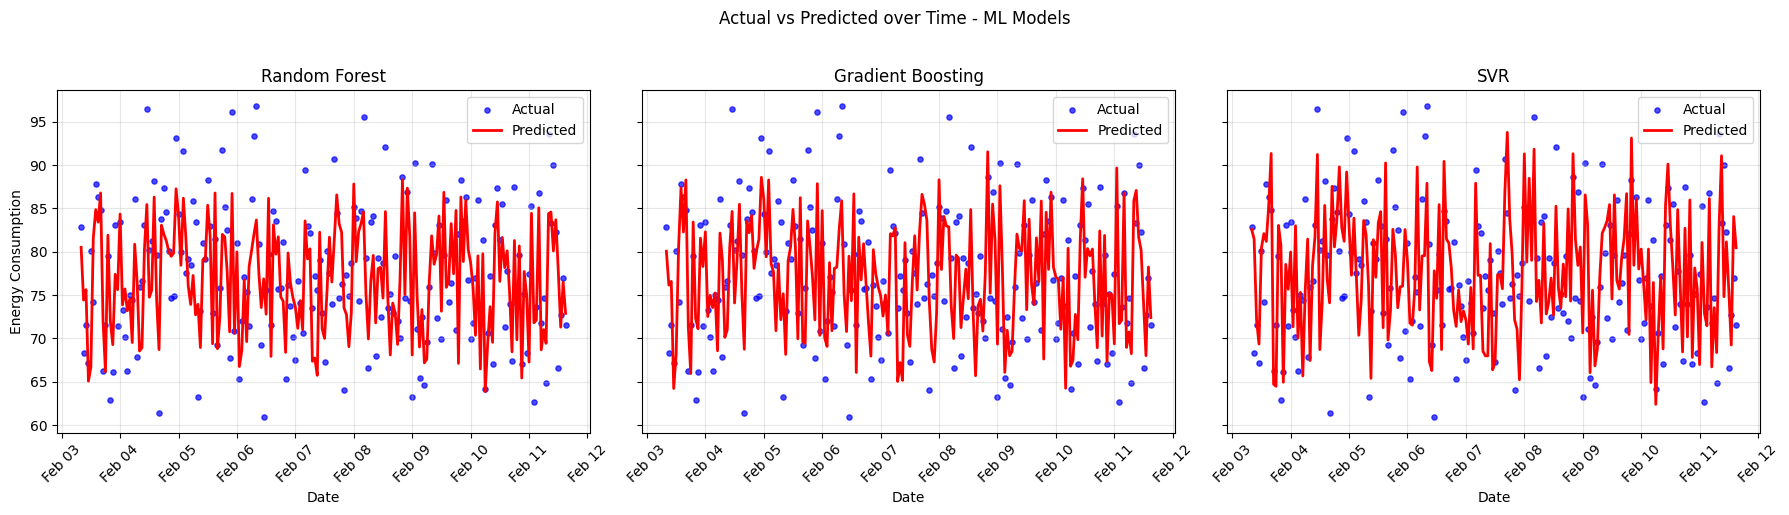

In [ ]:
# Actual vs Predicted Energy Consumption over Time (ML Advanced Models)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
model_names = list(test_frames.keys())

for i, name in enumerate(model_names):
    df_plot = test_frames[name]
    ax = axes[i]
    ax.scatter(df_plot['Timestamp'], df_plot['Actual'], s=14, alpha=0.7, label='Actual', color='blue')
    ax.plot(df_plot['Timestamp'], df_plot['Predicted'], linewidth=2, label='Predicted', color='red')
    ax.set_xlabel('Date')
    ax.set_title(f'{name}')
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    if i == 0:
        ax.set_ylabel('Energy Consumption')
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle('Actual vs Predicted over Time - ML Models', y=1.02)
plt.tight_layout()
plt.show()


# **Advanced Models: ARIMA, SARIMA, SARIMAX**
- Trained another three advanced models to try to  examine how explicit time-series forecasting impacts the prediction quality
- Used same scaled features and chronological train/test split as baseline.
- Results visualized for all models:
    - Actual vs Predicted energy consumption over time.
    - Average energy consumption by DayOfWeek.
    - Average and peak consumption by PartOfDay, split by Weekday/Weekend.

In [ ]:
# ==== Advanced Models: ARIMA, SARIMA, SARIMAX ====

# Train and predict using three advanced time series models.

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Prepare data (same as baseline)
# Use the df_scaled DataFrame which now includes lagged and rolling features from Feature Engineering
df = df_scaled.copy()

# Drop rows with NaNs introduced by shifted rolling windows (must be historical only)
df = df.dropna(subset=['EnergyConsumption_RollingMean_3h','EnergyConsumption_RollingMean_6h'])

# Ensure strictly chronological ordering
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.sort_values('Timestamp')

# Remove the very first few rows where lag features were zero padded (could bias model)
lag_cols = ['EnergyConsumption_Lag1','EnergyConsumption_Lag2','EnergyConsumption_Lag3']
mask_all_zero_lags = (df[lag_cols]==0).all(axis=1)
df = df[~mask_all_zero_lags]

# Feature list for exogenous variables (exclude the raw current target to avoid accidental reuse)
exog_features = ['Temperature', 'Humidity', 'Occupancy', 'SquareFootage', 'RenewableEnergy', 'EnergyPerOccupant_Lag1',
                 'EnergyConsumption_Lag1', 'EnergyConsumption_Lag2', 'EnergyConsumption_Lag3',
                 'EnergyConsumption_RollingMean_3h', 'EnergyConsumption_RollingMean_6h']

target = 'EnergyConsumption'

# Drop rows with missing values in required columns
needed_cols = ['Timestamp', target] + exog_features + ['DayOfWeek', 'PartOfDay']
df = df.dropna(subset=needed_cols)

X_exog = df[exog_features]
y = df[target].astype(float)
t = df['Timestamp']

# Ensure DayOfWeek is integer (0=Mon ... 6=Sun), Weekend flag
df['DayOfWeek'] = df['DayOfWeek'].astype(int)
df['Weekend'] = df['DayOfWeek'].isin([5, 6]).astype(int)

# Chronological train/test split (same as baseline)
split_idx = int(len(df) * 0.8)
X_exog_train, X_exog_test = X_exog.iloc[:split_idx], X_exog.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
t_test = t.iloc[split_idx:]
meta_test = df.iloc[split_idx:][['DayOfWeek', 'Weekend', 'PartOfDay']]

# Create time series with proper datetime index and frequency for ARIMA models
train_index = pd.to_datetime(t.iloc[:split_idx])
test_index = pd.to_datetime(t_test)

# Set explicit frequency to avoid warnings (assuming hourly data)
train_index = pd.DatetimeIndex(train_index).to_period('H').to_timestamp()
test_index = pd.DatetimeIndex(test_index).to_period('H').to_timestamp()

y_train_ts = pd.Series(y_train.values, index=train_index)
y_test_ts = pd.Series(y_test.values, index=test_index)

# Explicitly set frequency to hourly
y_train_ts.index.freq = 'H'

print(f"Time series frequency set to: {y_train_ts.index.freq}")
print(f"Training data range: {y_train_ts.index[0]} to {y_train_ts.index[-1]}")

# Store results for each model
adv_results = {}

# --- ARIMA ---
arima_model = ARIMA(y_train_ts, order=(5, 1, 0))
arima_fitted = arima_model.fit()  # Removed disp argument as it is no longer supported
y_pred_arima = arima_fitted.forecast(steps=len(y_test))
adv_results['ARIMA'] = y_pred_arima

# --- SARIMA ---
sarima_model = SARIMAX(y_train_ts, order=(1, 1, 1), seasonal_order=(1, 1, 1, 24), enforce_invertibility=False, enforce_stationarity=False)
sarima_fitted = sarima_model.fit()  # Removed disp argument as it is no longer supported
y_pred_sarima = sarima_fitted.forecast(steps=len(y_test))
adv_results['SARIMA'] = y_pred_sarima

# --- SARIMAX ---
X_exog_train_ts = pd.DataFrame(X_exog_train.values, index=train_index, columns=X_exog_train.columns)
X_exog_test_ts = pd.DataFrame(X_exog_test.values, index=test_index, columns=X_exog_test.columns)
sarimax_model = SARIMAX(y_train_ts, exog=X_exog_train_ts, order=(1, 1, 1), seasonal_order=(1, 1, 1, 24), enforce_invertibility=False, enforce_stationarity=False)
sarimax_fitted = sarimax_model.fit()  # Removed disp argument as it is no longer supported
y_pred_sarimax = sarimax_fitted.forecast(steps=len(y_test), exog=X_exog_test_ts)
adv_results['SARIMAX'] = y_pred_sarimax

# --- Collect test frame for each model (same structure as baseline) ---
test_frames = {}
ts_metrics = []

for name, preds in adv_results.items():
    test_frames[name] = pd.DataFrame({
        'Timestamp': t_test.values,
        'Actual': y_test.values,
        'Predicted': preds,
        'DayOfWeek': meta_test['DayOfWeek'].values,
        'Weekend': meta_test['Weekend'].values,
        'PartOfDay': meta_test['PartOfDay'].values
    }).sort_values('Timestamp')

    # Calculate R-squared score and format as percentage (same as baseline)
    r2 = r2_score(test_frames[name]['Actual'], test_frames[name]['Predicted'])
    r2_percentage = r2 * 100

    # Store metrics for table
    ts_metrics.append({
        'Model': name,
        'Accuracy (%)': f"{r2_percentage:.2f}%"
    })

# Display Time Series Models Performance Table
print(" TIME SERIES MODELS PERFORMANCE")
print("="*45)
ts_results_df = pd.DataFrame(ts_metrics).sort_values('Accuracy (%)', ascending=False, key=lambda x: x.str.rstrip('%').astype(float))
display(ts_results_df.reset_index(drop=True))

Time series frequency set to: <Hour>
Training data range: 2022-01-01 00:00:00 to 2022-02-03 07:00:00


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


📈 TIME SERIES MODELS PERFORMANCE


,Model,Accuracy (%)
0,SARIMAX,49.46%
1,SARIMA,-3.08%
2,ARIMA,-4.05%


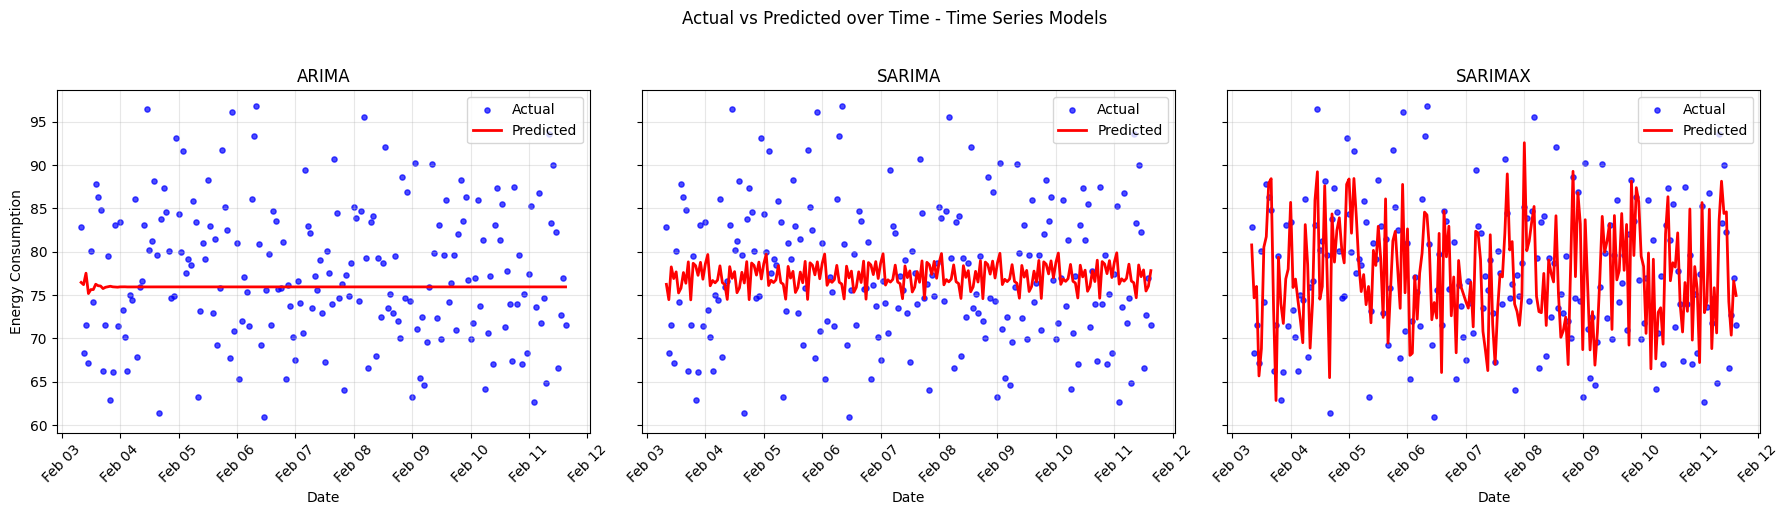

In [ ]:
# Actual vs Predicted Energy Consumption over Time (Time Series Models)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
model_names = list(test_frames.keys())

for i, name in enumerate(model_names):
    df_plot = test_frames[name]
    ax = axes[i]
    ax.scatter(df_plot['Timestamp'], df_plot['Actual'], s=14, alpha=0.7, label='Actual', color='blue')
    ax.plot(df_plot['Timestamp'], df_plot['Predicted'], linewidth=2, label='Predicted', color='red')
    ax.set_xlabel('Date')
    ax.set_title(f'{name}')
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    if i == 0:
        ax.set_ylabel('Energy Consumption')
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle('Actual vs Predicted over Time - Time Series Models', y=1.02)
plt.tight_layout()
plt.show()

# **Hyperparameter Tuning**

Applied Hyperparameter Tuning for all models to maximize the
predictive performance, ensure fair benchmarking across all models

In [ ]:
# ==== Hyperparameter Tuning for All Models ====

import itertools
import warnings
warnings.filterwarnings("ignore")
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
import pandas as pd

print("Tuning hyperparameters for all models...")

# === 1. Linear Regression Variants Tuning ===
# Test different linear models: LinearRegression, Ridge, Lasso
linear_models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(max_iter=2000)
}

# Ridge and Lasso parameter grids (use 'alpha' directly, not 'lr__alpha')
param_grids = {
    'LinearRegression': {},
    'Ridge': {'alpha': [0.1, 1.0, 10.0, 100.0]},
    'Lasso': {'alpha': [0.01, 0.1, 1.0, 10.0]}
}

linear_results = {}
# Use the same variables from baseline model section
original_lr_r2 = r2_score(y_test, y_pred)  # y_pred from baseline model

best_linear_model = None
best_linear_r2 = original_lr_r2

for name, model in linear_models.items():
    if param_grids[name]:  # If there are parameters to tune
        grid = GridSearchCV(model, param_grids[name], cv=3, scoring='r2', n_jobs=-1)
        grid.fit(X_train, y_train)
        y_pred_tuned = grid.predict(X_test)
        tuned_r2 = r2_score(y_test, y_pred_tuned)
        linear_results[name] = {'original': original_lr_r2, 'tuned': tuned_r2, 'best_params': grid.best_params_}
    else:  # LinearRegression has no hyperparameters
        model.fit(X_train, y_train)
        y_pred_model = model.predict(X_test)
        tuned_r2 = r2_score(y_test, y_pred_model)
        linear_results[name] = {'original': original_lr_r2, 'tuned': tuned_r2, 'best_params': 'default'}

    if tuned_r2 > best_linear_r2:
        best_linear_r2 = tuned_r2
        best_linear_model = name

# === 2. ML Models Tuning ===
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

# ML models and their parameter grids
ml_models = {
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'SVR': SVR()
}

ml_param_grids = {
    'Random Forest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [10, 15, 20],
        'min_samples_split': [2, 5, 10]
    },
    'Gradient Boosting': {
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 6, 10],
        'learning_rate': [0.01, 0.1, 0.2]
    },
    'SVR': {
        'C': [10, 100, 1000],
        'gamma': ['scale', 'auto', 0.001, 0.01],
        'kernel': ['rbf', 'poly']
    }
}

# Store ML tuning results
ml_tuning_results = {}

# Original ML model performances (from the ML models section)
# Use the existing ML model predictions that were already calculated
original_ml_results = {
    'Random Forest': r2_score(y_test, y_pred_rf),
    'Gradient Boosting': r2_score(y_test, y_pred_gb),
    'SVR': r2_score(y_test, y_pred_svr)
}

# Tune each ML model
for name, model in ml_models.items():
    print(f"Tuning {name}...")
    grid = GridSearchCV(model, ml_param_grids[name], cv=3, scoring='r2', n_jobs=-1)
    grid.fit(X_exog_train, y_train)
    y_pred_tuned = grid.predict(X_exog_test)
    tuned_r2 = r2_score(y_test, y_pred_tuned)

    ml_tuning_results[name] = {
        'original': original_ml_results[name],
        'tuned': tuned_r2,
        'best_params': grid.best_params_
    }

# === 3. Time Series Models Tuning ===
def arima_order_search(y, p_range=range(0,4), d_range=range(0,3), q_range=range(0,4)):
    best_aic = float('inf')
    best_order = None
    for p, d, q in itertools.product(p_range, d_range, q_range):
        try:
            model = ARIMA(y, order=(p, d, q))
            fitted = model.fit()
            if fitted.aic < best_aic:
                best_aic = fitted.aic
                best_order = (p, d, q)
        except:
            continue
    return best_order, best_aic

def sarima_order_search(y, seasonal_period=24,
                       p_range=range(0,3), d_range=range(0,2), q_range=range(0,3),
                       P_range=range(0,2), D_range=range(0,2), Q_range=range(0,2)):
    best_aic = float('inf')
    best_orders = None
    for p, d, q in itertools.product(p_range, d_range, q_range):
        for P, D, Q in itertools.product(P_range, D_range, Q_range):
            try:
                model = SARIMAX(y, order=(p, d, q), seasonal_order=(P, D, Q, seasonal_period),
                               enforce_stationarity=False, enforce_invertibility=False)
                fitted = model.fit(disp=False)
                if fitted.aic < best_aic:
                    best_aic = fitted.aic
                    best_orders = ((p, d, q), (P, D, Q, seasonal_period))
            except:
                continue
    return best_orders, best_aic

# Original time series model performances (from advanced models section)
original_ts_results = {}

# Original ARIMA
arima_orig = ARIMA(y_train_ts, order=(5, 1, 0)).fit()
y_pred_orig_arima = arima_orig.forecast(steps=len(y_test))
original_ts_results['ARIMA'] = {'r2': r2_score(y_test, y_pred_orig_arima), 'order': (5, 1, 0)}

# Original SARIMA
sarima_orig = SARIMAX(y_train_ts, order=(1, 1, 1), seasonal_order=(1, 1, 1, 24),
                     enforce_stationarity=False, enforce_invertibility=False).fit()
y_pred_orig_sarima = sarima_orig.forecast(steps=len(y_test))
original_ts_results['SARIMA'] = {'r2': r2_score(y_test, y_pred_orig_sarima), 'order': ((1, 1, 1), (1, 1, 1, 24))}

# Original SARIMAX
sarimax_orig = SARIMAX(y_train_ts, exog=X_exog_train_ts, order=(1, 1, 1), seasonal_order=(1, 1, 1, 24),
                      enforce_stationarity=False, enforce_invertibility=False).fit()
y_pred_orig_sarimax = sarimax_orig.forecast(steps=len(y_test), exog=X_exog_test_ts)
original_ts_results['SARIMAX'] = {'r2': r2_score(y_test, y_pred_orig_sarimax), 'order': ((1, 1, 1), (1, 1, 1, 24))}

# Find optimal parameters
best_arima_order, _ = arima_order_search(y_train_ts)
best_sarima_orders, _ = sarima_order_search(y_train_ts)
best_sarimax_orders, _ = sarima_order_search(y_train_ts)  # Same search for SARIMAX base order

# Train tuned models
tuned_ts_results = {}

# Tuned ARIMA
arima_tuned = ARIMA(y_train_ts, order=best_arima_order).fit()
y_pred_tuned_arima = arima_tuned.forecast(steps=len(y_test))
tuned_ts_results['ARIMA'] = {'r2': r2_score(y_test, y_pred_tuned_arima), 'order': best_arima_order}

# Tuned SARIMA
sarima_tuned = SARIMAX(y_train_ts, order=best_sarima_orders[0], seasonal_order=best_sarima_orders[1],
                      enforce_stationarity=False, enforce_invertibility=False).fit()
y_pred_tuned_sarima = sarima_tuned.forecast(steps=len(y_test))
tuned_ts_results['SARIMA'] = {'r2': r2_score(y_test, y_pred_tuned_sarima), 'order': best_sarima_orders}

# Tuned SARIMAX
sarimax_tuned = SARIMAX(y_train_ts, exog=X_exog_train_ts, order=best_sarimax_orders[0], seasonal_order=best_sarimax_orders[1],
                       enforce_stationarity=False, enforce_invertibility=False).fit()
y_pred_tuned_sarimax = sarimax_tuned.forecast(steps=len(y_test), exog=X_exog_test_ts)
tuned_ts_results['SARIMAX'] = {'r2': r2_score(y_test, y_pred_tuned_sarimax), 'order': best_sarimax_orders}

# === 4. Create Final Comparison Table ===
comparison_data = []

# Add best linear model
best_linear_result = linear_results[best_linear_model]
improvement_linear = ((best_linear_result['tuned'] - best_linear_result['original']) / abs(best_linear_result['original'])) * 100
comparison_data.append({
    'Model': f'Linear Regression ({best_linear_model})',
    'Accuracy_Before_Tuning (%)': f"{best_linear_result['original'] * 100:.2f}",
    'Accuracy_After_Tuning (%)': f"{best_linear_result['tuned'] * 100:.2f}",
    'Improvement (%)': f"{improvement_linear:.2f}",
    'Best_Parameters': str(best_linear_result['best_params'])
})

# Add ML models
for model in ['Random Forest', 'Gradient Boosting', 'SVR']:
    original_r2 = ml_tuning_results[model]['original']
    tuned_r2 = ml_tuning_results[model]['tuned']
    improvement = ((tuned_r2 - original_r2) / abs(original_r2)) * 100 if original_r2 != 0 else 0

    comparison_data.append({
        'Model': model,
        'Accuracy_Before_Tuning (%)': f"{original_r2 * 100:.2f}",
        'Accuracy_After_Tuning (%)': f"{tuned_r2 * 100:.2f}",
        'Improvement (%)': f"{improvement:.2f}",
        'Best_Parameters': str(ml_tuning_results[model]['best_params'])
    })

# Add time series models
for model in ['ARIMA', 'SARIMA', 'SARIMAX']:
    original_r2 = original_ts_results[model]['r2']
    tuned_r2 = tuned_ts_results[model]['r2']
    improvement = ((tuned_r2 - original_r2) / abs(original_r2)) * 100 if original_r2 != 0 else 0

    comparison_data.append({
        'Model': model,
        'Accuracy_Before_Tuning (%)': f"{original_r2 * 100:.2f}",
        'Accuracy_After_Tuning (%)': f"{tuned_r2 * 100:.2f}",
        'Improvement (%)': f"{improvement:.2f}",
        'Best_Parameters': str(tuned_ts_results[model]['order'])
    })

comparison_df = pd.DataFrame(comparison_data)
print("\n=== Hyperparameter Tuning Results for All Models ===")
display(comparison_df)

Tuning hyperparameters for all models...
Tuning Random Forest...
Tuning Gradient Boosting...
Tuning SVR...

=== Hyperparameter Tuning Results for All Models ===


,Model,Accuracy_Before_Tuning (%),Accuracy_After_Tuning (%),Improvement (%),Best_Parameters
0,Linear Regression (Lasso),50.99,51.97,1.92,{'alpha': 0.1}
1,Random Forest,49.37,49.30,-0.13,"{'max_depth': 15, 'min_samples_split': 10, 'n_..."
2,Gradient Boosting,45.64,51.05,11.85,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti..."
3,SVR,26.14,52.51,100.90,"{'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}"
4,ARIMA,-4.05,-1.06,73.79,"(2, 1, 3)"
5,SARIMA,-3.08,-3.41,-10.52,"((1, 1, 2), (0, 1, 1, 24))"
6,SARIMAX,49.46,49.80,0.69,"((1, 1, 2), (0, 1, 1, 24))"


# **Evaluating ARIMA, SARIMA, SARIMAX**
Evaluated the performance of each advanced model using RMSE, MAE, and R^2

In [ ]:
# ==== Model Evaluation ====

evaluation_metrics = {}

for name, df_plot in test_frames.items():
    # Calculate RMSE manually by taking the square root
    rmse = np.sqrt(mean_squared_error(df_plot['Actual'], df_plot['Predicted']))
    mae = mean_absolute_error(df_plot['Actual'], df_plot['Predicted'])
    r2 = r2_score(df_plot['Actual'], df_plot['Predicted'])
    evaluation_metrics[name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}

# Display evaluation metrics
print("Model Evaluation Metrics:")
display(pd.DataFrame(evaluation_metrics).T)

Model Evaluation Metrics:


,RMSE,MAE,R2
ARIMA,7.985110,6.473433,-0.040481
SARIMA,7.947933,6.400792,-0.030815
SARIMAX,5.565448,4.570372,0.494556


## **Visualization: Actual vs Predicted**

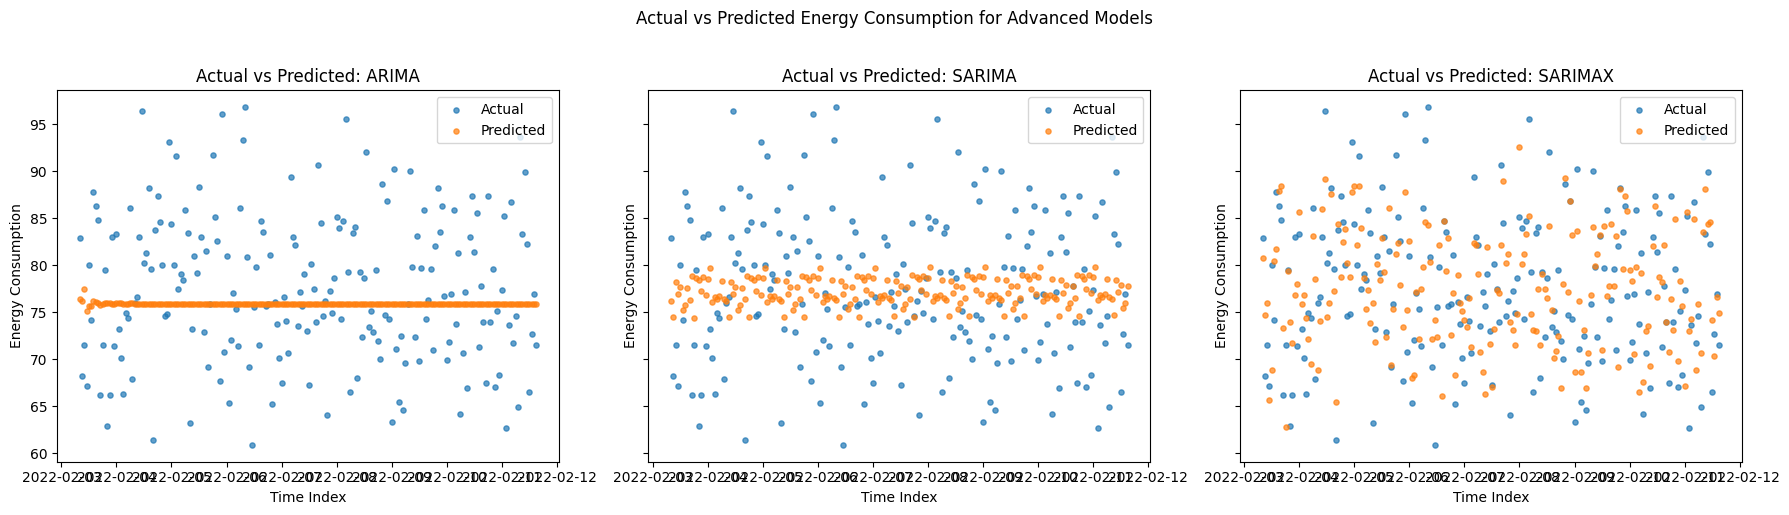

In [ ]:
# Visualize Actual vs Predicted Energy Consumption for each model

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
model_names = list(test_frames.keys())

for i, name in enumerate(model_names):
    df_plot = test_frames[name]
    ax = axes[i]

    ax.scatter(df_plot.index, df_plot['Actual'], s=14, alpha=0.7, label='Actual')
    ax.scatter(df_plot.index, df_plot['Predicted'], s=14, alpha=0.7, label='Predicted')

    ax.set_xlabel('Time Index')
    ax.set_ylabel('Energy Consumption')
    ax.set_title(f'Actual vs Predicted: {name}')
    ax.legend()

fig.suptitle('Actual vs Predicted Energy Consumption for Advanced Models', y=1.02)
plt.tight_layout()
plt.show()

## **Model Selection & Detailed Analysis**
After comparing all model accuracies above, we analyzed the patterns of the best performing model with the following plots:

In [ ]:
# ==== Model Selection & Pattern Analysis ====

# Combine all model results including baseline for comparison
import matplotlib.dates as mdates

# Create a comprehensive results dictionary
all_models_results = {}

# Add baseline model (test_df from baseline section)
all_models_results['Linear Regression (Baseline)'] = test_df

# Add advanced models (test_frames from advanced sections)
all_models_results.update(test_frames)

# Display accuracy comparison table
print("=== ALL MODELS ACCURACY COMPARISON ===")
accuracy_comparison = []
for model_name, model_df in all_models_results.items():
    r2 = r2_score(model_df['Actual'], model_df['Predicted'])
    accuracy_comparison.append({
        'Model': model_name,
        'Accuracy (%)': f"{r2 * 100:.2f}%",
        'R²': f"{r2:.4f}"
    })

comparison_df = pd.DataFrame(accuracy_comparison).sort_values('R²', ascending=False)
display(comparison_df)

# Identify best model
best_model_name = comparison_df.iloc[0]['Model']
best_model_df = all_models_results[best_model_name]

print(f"\n BEST MODEL: {best_model_name}")
print(f"Best Accuracy: {comparison_df.iloc[0]['Accuracy (%)']}")

=== ALL MODELS ACCURACY COMPARISON ===


,Model,Accuracy (%),R²
0,Linear Regression (Baseline),50.99%,0.5099
3,SARIMAX,49.46%,0.4946
1,ARIMA,-4.05%,-0.0405
2,SARIMA,-3.08%,-0.0308



🏆 BEST MODEL: Linear Regression (Baseline)
Best Accuracy: 50.99%


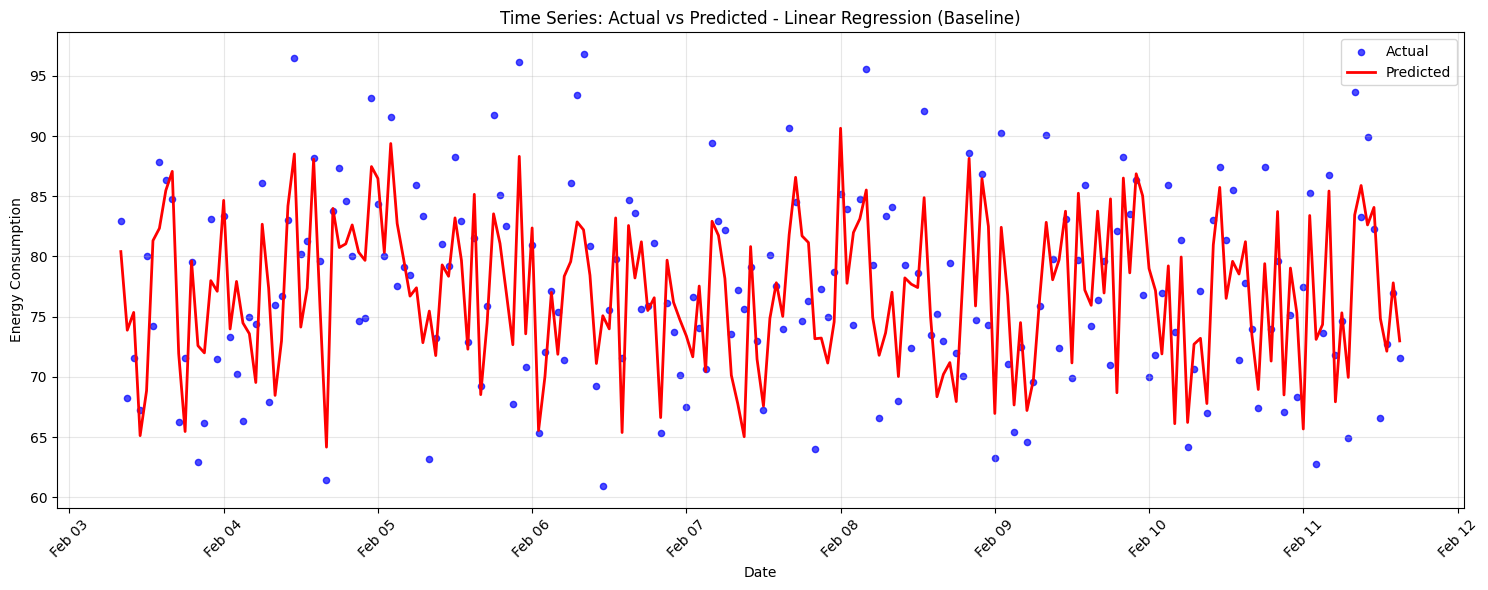

In [ ]:
# ==== Time Series Analysis of Best Model ====

plt.figure(figsize=(15, 6))
plt.scatter(best_model_df['Timestamp'], best_model_df['Actual'], s=20, alpha=0.7, label='Actual', color='blue')
plt.plot(best_model_df['Timestamp'], best_model_df['Predicted'], linewidth=2, label='Predicted', color='red')
plt.xlabel('Date')
plt.ylabel('Energy Consumption')
plt.title(f'Time Series: Actual vs Predicted - {best_model_name}')
plt.legend()
plt.grid(True, alpha=0.3)

# Improve time axis formatting
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

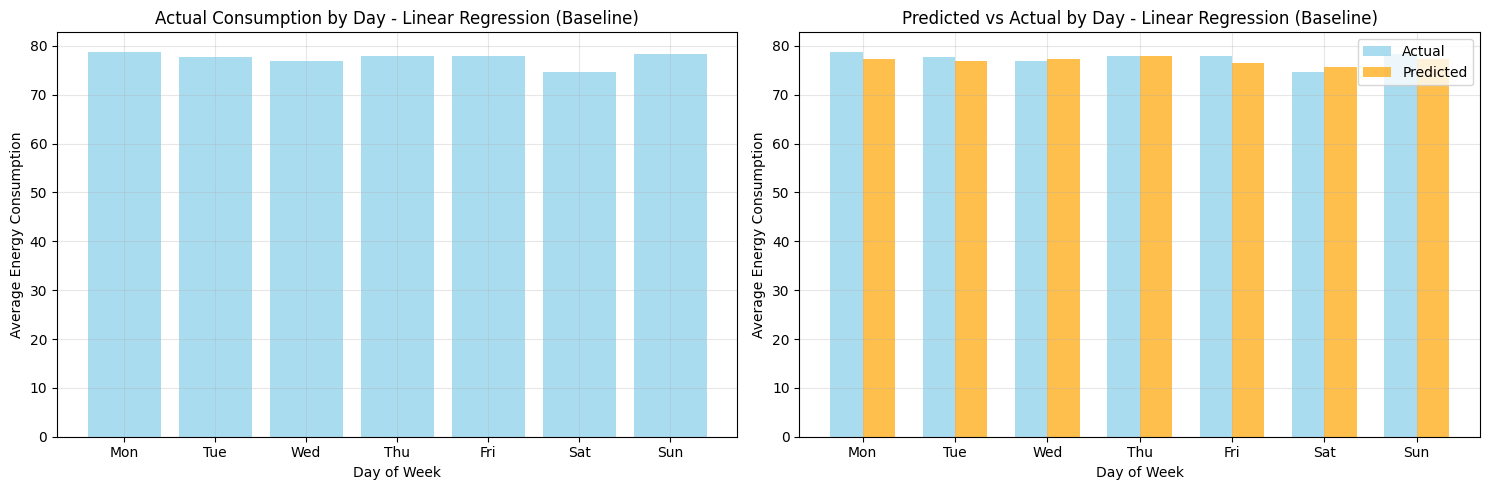

In [ ]:
# ==== Weekly Pattern Analysis (DayOfWeek) ====

# Average actual consumption by day of week
avg_actual_dow = best_model_df.groupby('DayOfWeek')['Actual'].mean()
avg_pred_dow = best_model_df.groupby('DayOfWeek')['Predicted'].mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Actual consumption by day
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
ax1.bar(range(7), avg_actual_dow, color='skyblue', alpha=0.7)
ax1.set_xticks(range(7))
ax1.set_xticklabels(day_labels)
ax1.set_xlabel('Day of Week')
ax1.set_ylabel('Average Energy Consumption')
ax1.set_title(f'Actual Consumption by Day - {best_model_name}')
ax1.grid(True, alpha=0.3)

# Predicted vs Actual comparison
x = range(7)
width = 0.35
ax2.bar([i - width/2 for i in x], avg_actual_dow, width, label='Actual', color='skyblue', alpha=0.7)
ax2.bar([i + width/2 for i in x], avg_pred_dow, width, label='Predicted', color='orange', alpha=0.7)
ax2.set_xticks(x)
ax2.set_xticklabels(day_labels)
ax2.set_xlabel('Day of Week')
ax2.set_ylabel('Average Energy Consumption')
ax2.set_title(f'Predicted vs Actual by Day - {best_model_name}')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

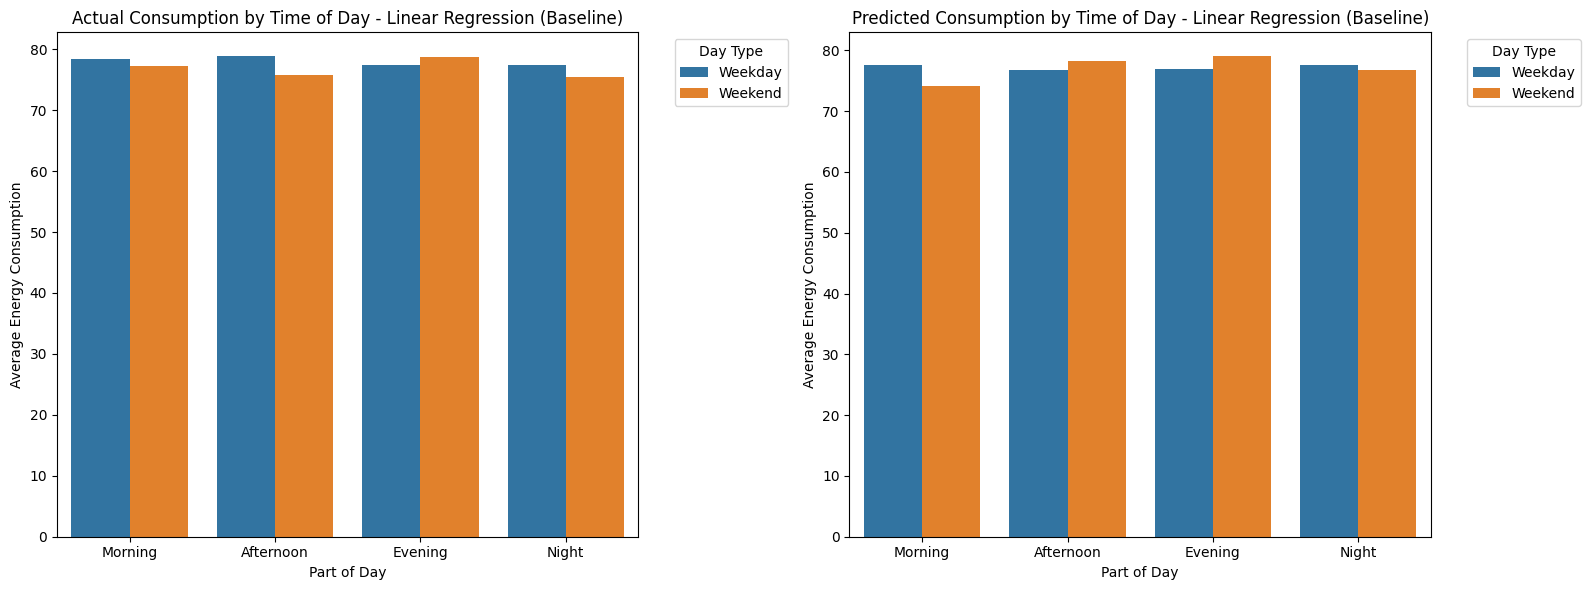


📊 PATTERN INSIGHTS FOR Linear Regression (Baseline):
Average Weekday Consumption: 77.97
Average Weekend Consumption: 76.55
Weekend vs Weekday Difference: -1.8%
Peak Consumption Time: Afternoon on Weekdays (78.82)

Model Accuracy by Time Period:
Morning:   50.0%
Afternoon: 50.6%
Evening:   37.5%
Night:     57.1%


In [ ]:
# ==== Daily Pattern Analysis (PartOfDay) ====

# Prepare data with proper labeling
analysis_df = best_model_df.copy()
analysis_df['Day Type'] = analysis_df['Weekend'].map({0: 'Weekday', 1: 'Weekend'})

# Calculate averages for actual and predicted
avg_actual_pod = analysis_df.groupby(['PartOfDay', 'Day Type'])['Actual'].mean().reset_index()
avg_pred_pod = analysis_df.groupby(['PartOfDay', 'Day Type'])['Predicted'].mean().reset_index()

# Set proper order for parts of day
partofday_order = ['Morning', 'Afternoon', 'Evening', 'Night']
avg_actual_pod['PartOfDay'] = pd.Categorical(avg_actual_pod['PartOfDay'], categories=partofday_order, ordered=True)
avg_pred_pod['PartOfDay'] = pd.Categorical(avg_pred_pod['PartOfDay'], categories=partofday_order, ordered=True)
avg_actual_pod = avg_actual_pod.sort_values('PartOfDay')
avg_pred_pod = avg_pred_pod.sort_values('PartOfDay')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Actual consumption by part of day
sns.barplot(data=avg_actual_pod, x='PartOfDay', y='Actual', hue='Day Type',
           palette=['#1f77b4', '#ff7f0e'], ax=ax1)
ax1.set_title(f'Actual Consumption by Time of Day - {best_model_name}')
ax1.set_xlabel('Part of Day')
ax1.set_ylabel('Average Energy Consumption')
ax1.legend(title='Day Type', bbox_to_anchor=(1.05, 1), loc='upper left')

# Predicted consumption by part of day
sns.barplot(data=avg_pred_pod, x='PartOfDay', y='Predicted', hue='Day Type',
           palette=['#1f77b4', '#ff7f0e'], ax=ax2)
ax2.set_title(f'Predicted Consumption by Time of Day - {best_model_name}')
ax2.set_xlabel('Part of Day')
ax2.set_ylabel('Average Energy Consumption')
ax2.legend(title='Day Type', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Display insights
print(f"\n📊 PATTERN INSIGHTS FOR {best_model_name}:")
print("="*50)

# Weekend vs Weekday
weekend_avg = analysis_df[analysis_df['Weekend'] == 1]['Actual'].mean()
weekday_avg = analysis_df[analysis_df['Weekend'] == 0]['Actual'].mean()
print(f"Average Weekday Consumption: {weekday_avg:.2f}")
print(f"Average Weekend Consumption: {weekend_avg:.2f}")
print(f"Weekend vs Weekday Difference: {((weekend_avg - weekday_avg) / weekday_avg * 100):+.1f}%")

# Peak consumption times
peak_time = avg_actual_pod.loc[avg_actual_pod['Actual'].idxmax(), 'PartOfDay']
peak_day_type = avg_actual_pod.loc[avg_actual_pod['Actual'].idxmax(), 'Day Type']
peak_value = avg_actual_pod['Actual'].max()
print(f"Peak Consumption Time: {peak_time} on {peak_day_type}s ({peak_value:.2f})")

# Model accuracy by time periods
morning_r2 = r2_score(analysis_df[analysis_df['PartOfDay'] == 'Morning']['Actual'],
                     analysis_df[analysis_df['PartOfDay'] == 'Morning']['Predicted'])
afternoon_r2 = r2_score(analysis_df[analysis_df['PartOfDay'] == 'Afternoon']['Actual'],
                       analysis_df[analysis_df['PartOfDay'] == 'Afternoon']['Predicted'])
evening_r2 = r2_score(analysis_df[analysis_df['PartOfDay'] == 'Evening']['Actual'],
                     analysis_df[analysis_df['PartOfDay'] == 'Evening']['Predicted'])
night_r2 = r2_score(analysis_df[analysis_df['PartOfDay'] == 'Night']['Actual'],
                   analysis_df[analysis_df['PartOfDay'] == 'Night']['Predicted'])

print(f"\nModel Accuracy by Time Period:")
print(f"Morning:   {morning_r2 * 100:.1f}%")
print(f"Afternoon: {afternoon_r2 * 100:.1f}%")
print(f"Evening:   {evening_r2 * 100:.1f}%")
print(f"Night:     {night_r2 * 100:.1f}%")

# **Final Model Evaluation and Selection**


*  Re-calculated the metrics for all models




In [ ]:


from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("=== FINAL MODEL EVALUATION ===")
print("="*30)

# Re-calculate metrics for baseline and original advanced models
final_evaluation_data = []

# Baseline Linear Regression (using test_df from the baseline section)
rmse_lr = np.sqrt(mean_squared_error(test_df['Actual'], test_df['Predicted']))
mae_lr = mean_absolute_error(test_df['Actual'], test_df['Predicted'])
r2_lr = r2_score(test_df['Actual'], test_df['Predicted']) * 100
final_evaluation_data.append({
    'Model': 'Linear Regression (Baseline)',
    'R² (%)': f"{r2_lr:.2f}",
    'RMSE': f"{rmse_lr:.2f}",
    'MAE': f"{mae_lr:.2f}"
})

# Original Advanced Models (using test_frames from the advanced models section)
for name, df_plot in test_frames.items():
    rmse = np.sqrt(mean_squared_error(df_plot['Actual'], df_plot['Predicted']))
    mae = mean_absolute_error(df_plot['Actual'], df_plot['Predicted'])
    r2 = r2_score(df_plot['Actual'], df_plot['Predicted']) * 100
    final_evaluation_data.append({
        'Model': f'{name} (Original)',
        'R² (%)': f"{r2:.2f}",
        'RMSE': f"{rmse:.2f}",
        'MAE': f"{mae:.2f}"
    })

# Tuned Models (using the results from hyperparameter tuning section)
# Linear Regression Variants
for name, result in linear_results.items():
    # We need to predict again with the best tuned model to get metrics on the test set
    if name == 'LinearRegression':
        model = LinearRegression()
        model.fit(X_train, y_train)
    elif name == 'Ridge':
        model = Ridge(**result['best_params'])
        model.fit(X_train, y_train)
    elif name == 'Lasso':
        model = Lasso(**result['best_params'])
        model.fit(X_train, y_train)

    y_pred_tuned = model.predict(X_test)
    rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
    mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
    r2_tuned = r2_score(y_test, y_pred_tuned) * 100

    final_evaluation_data.append({
        'Model': f'Linear Regression ({name} - Tuned)',
        'R² (%)': f"{r2_tuned:.2f}",
        'RMSE': f"{rmse_tuned:.2f}",
        'MAE': f"{mae_tuned:.2f}"
    })

# ML Models
for name, result in ml_tuning_results.items():
    if name == 'Random Forest':
        model = RandomForestRegressor(random_state=42, **result['best_params'])
        model.fit(X_exog_train, y_train)
    elif name == 'Gradient Boosting':
        model = GradientBoostingRegressor(random_state=42, **result['best_params'])
        model.fit(X_exog_train, y_train)
    elif name == 'SVR':
        model = SVR(**result['best_params'])
        model.fit(X_exog_train, y_train)

    y_pred_tuned = model.predict(X_exog_test)
    rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
    mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
    r2_tuned = r2_score(y_test, y_pred_tuned) * 100

    final_evaluation_data.append({
        'Model': f'{name} (Tuned)',
        'R² (%)': f"{r2_tuned:.2f}",
        'RMSE': f"{rmse_tuned:.2f}",
        'MAE': f"{mae_tuned:.2f}"
    })

# Time Series Models
for name, result in tuned_ts_results.items():
    if name == 'ARIMA':
        model = ARIMA(y_train_ts, order=result['order'])
        fitted = model.fit()
        y_pred_tuned = fitted.forecast(steps=len(y_test_ts))
    elif name == 'SARIMA':
         model = SARIMAX(y_train_ts, order=result['order'][0], seasonal_order=result['order'][1],
                        enforce_stationarity=False, enforce_invertibility=False)
         fitted = model.fit(disp=False)
         y_pred_tuned = fitted.forecast(steps=len(y_test_ts))
    elif name == 'SARIMAX':
         model = SARIMAX(y_train_ts, exog=X_exog_train_ts, order=result['order'][0], seasonal_order=result['order'][1],
                        enforce_stationarity=False, enforce_invertibility=False)
         fitted = model.fit(disp=False)
         y_pred_tuned = fitted.forecast(steps=len(y_test_ts), exog=X_exog_test_ts)

    rmse_tuned = np.sqrt(mean_squared_error(y_test_ts, y_pred_tuned))
    mae_tuned = mean_absolute_error(y_test_ts, y_pred_tuned)
    r2_tuned = r2_score(y_test_ts, y_pred_tuned) * 100

    final_evaluation_data.append({
        'Model': f'{name} (Tuned)',
        'R² (%)': f"{r2_tuned:.2f}",
        'RMSE': f"{rmse_tuned:.2f}",
        'MAE': f"{mae_tuned:.2f}"
    })


final_evaluation_df = pd.DataFrame(final_evaluation_data)

# Sort by R² (%) for easy comparison
final_evaluation_df['R² (%)_float'] = final_evaluation_df['R² (%)'].astype(float)
final_evaluation_df_sorted = final_evaluation_df.sort_values(by='R² (%)_float', ascending=False).drop(columns='R² (%)_float').reset_index(drop=True)

display(final_evaluation_df_sorted)

# Determine the best model
best_model_name = final_evaluation_df_sorted.iloc[0]['Model']
print(f"\n Based on the R² metric, the best performing model is: {best_model_name}")

=== FINAL MODEL EVALUATION ===


,Model,R² (%),RMSE,MAE
0,SVR (Tuned),52.51,5.39,4.35
1,Linear Regression (Lasso - Tuned),51.97,5.43,4.37
2,Linear Regression (Ridge - Tuned),51.09,5.47,4.41
3,Gradient Boosting (Tuned),51.05,5.48,4.47
4,Linear Regression (Baseline),50.99,5.48,4.41
5,Linear Regression (LinearRegression - Tuned),50.99,5.48,4.41
6,SARIMAX (Tuned),49.80,5.55,4.55
7,SARIMAX (Original),49.46,5.57,4.57
8,Random Forest (Tuned),49.30,5.57,4.53
9,ARIMA (Tuned),-1.06,7.87,6.45



 Based on the R² metric, the best performing model is: SVR (Tuned)


# **Final Evaluation Visualization**

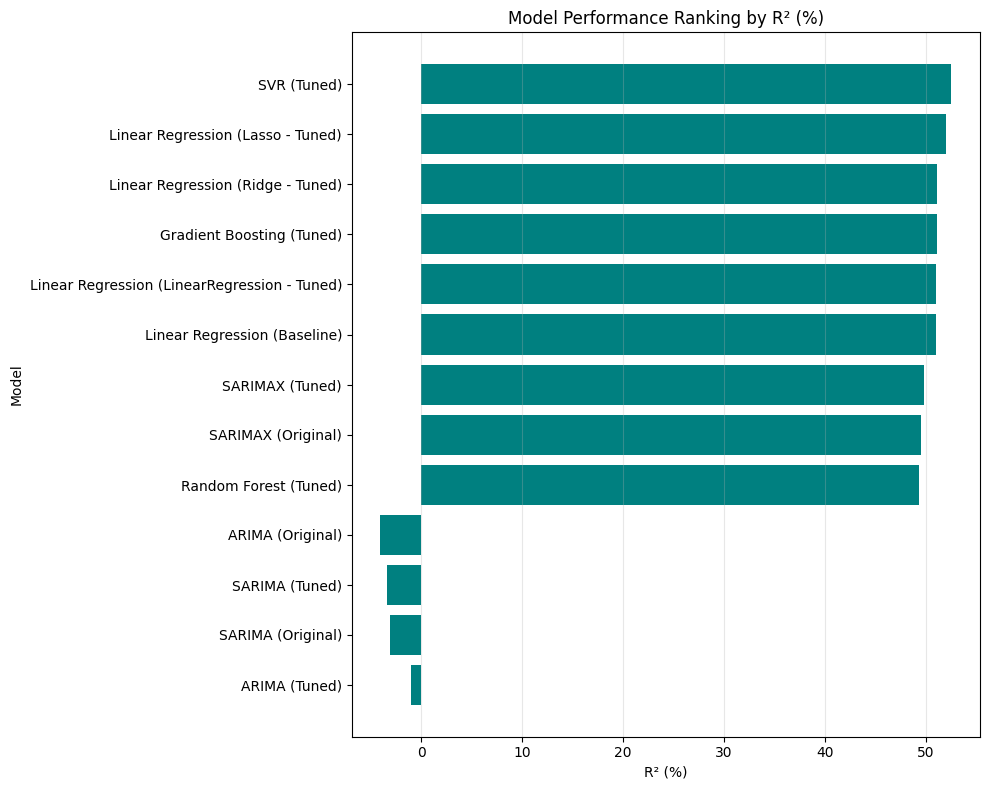

In [ ]:
# Horizontal ranking chart: sorted R² (%) to highlight winner

import matplotlib.pyplot as plt
import pandas as pd

# Ensure final_evaluation_df_sorted is available
if 'final_evaluation_df_sorted' in locals():
    # Sort by R² (%) for ranking
    ranked_r2 = final_evaluation_df_sorted.sort_values('R² (%)', ascending=True)

    plt.figure(figsize=(10, 8))
    plt.barh(ranked_r2['Model'], ranked_r2['R² (%)'].astype(float), color='teal')
    plt.xlabel('R² (%)')
    plt.ylabel('Model')
    plt.title('Model Performance Ranking by R² (%)')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Final evaluation data not available for R² ranking chart.")

# **Best Model (SVR) Visualization**

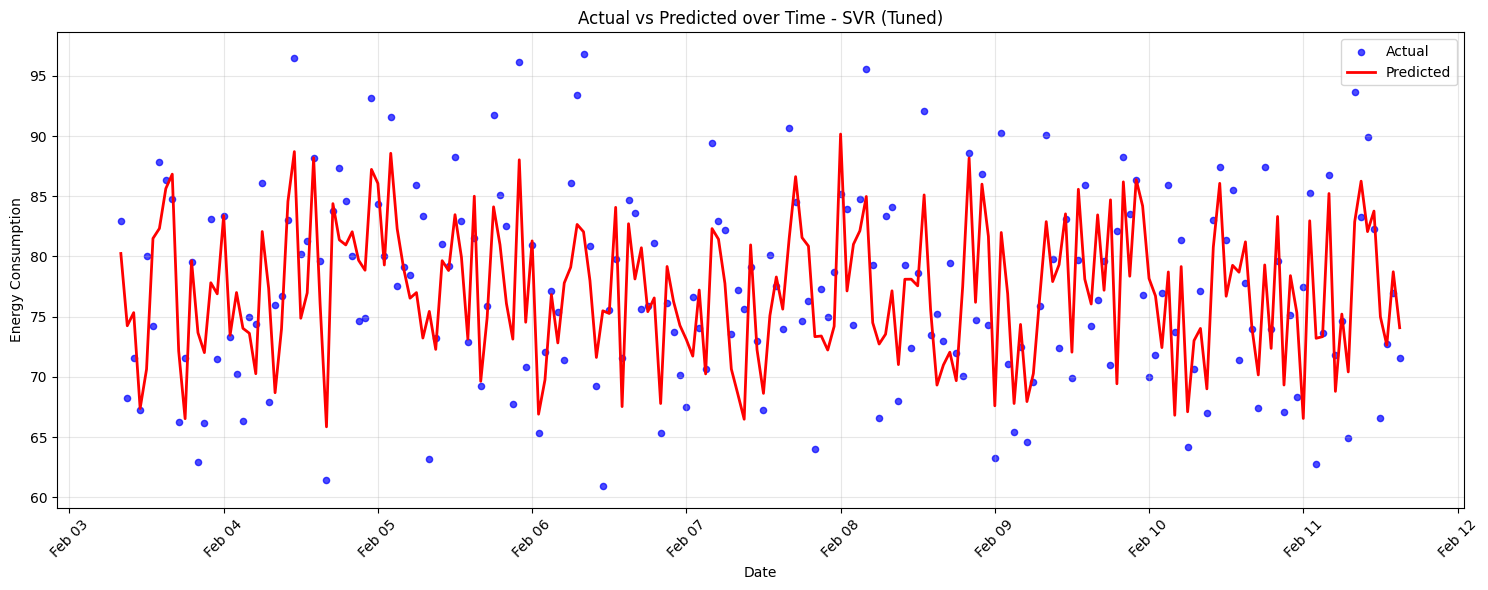

In [ ]:
# Actual vs Predicted line plot for the best model (SVR)

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX


# Ensure necessary variables from previous cells are available
# df_scaled, X_exog_train, X_exog_test, y_train, y_test, t_test, meta_test,
# tuned_ts_results, y_train_ts, y_test_ts, X_exog_train_ts, X_exog_test_ts
# ml_tuning_results, linear_results, X_train, X_test

# Re-generate the test_frame for the best tuned model (SVR) as identified in the final evaluation
best_model_name_final = final_evaluation_df_sorted.iloc[0]['Model'] # Should be 'SVR (Tuned)'

# --- Re-predict for the best model (SVR Tuned) ---
# Assuming SVR (Tuned) is indeed the best based on the previous output
if best_model_name_final == 'SVR (Tuned)':
    best_params_svr = ml_tuning_results['SVR']['best_params']
    best_svr_model = SVR(**best_params_svr)
    best_svr_model.fit(X_exog_train, y_train)
    y_pred_best_svr = best_svr_model.predict(X_exog_test)

    best_svr_test_frame = pd.DataFrame({
        'Timestamp': t_test.values,
        'Actual': y_test.values,
        'Predicted': y_pred_best_svr,
        'DayOfWeek': meta_test['DayOfWeek'].values,
        'Weekend': meta_test['Weekend'].values,
        'PartOfDay': meta_test['PartOfDay'].values
    }).sort_values('Timestamp')

    # Plotting
    plt.figure(figsize=(15, 6))
    plt.scatter(best_svr_test_frame['Timestamp'], best_svr_test_frame['Actual'], s=20, alpha=0.7, label='Actual', color='blue')
    plt.plot(best_svr_test_frame['Timestamp'], best_svr_test_frame['Predicted'], linewidth=2, label='Predicted', color='red')
    plt.xlabel('Date')
    plt.ylabel('Energy Consumption')
    plt.title(f'Actual vs Predicted over Time - {best_model_name_final}')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Improve time axis formatting
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

else:
    print(f"The best model is not SVR (Tuned) as expected. Best model is: {best_model_name_final}")
    print("Skipping Actual vs Predicted plot for SVR.")

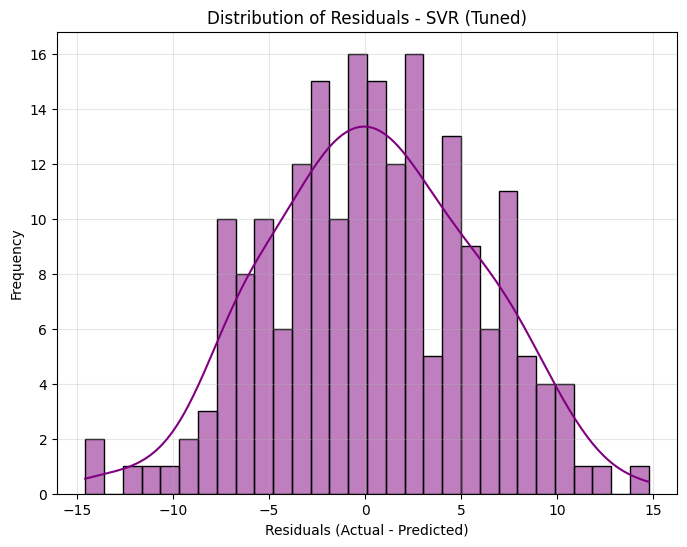

In [ ]:
# Residual histogram for the best model (SVR)

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure best_svr_test_frame is available from the previous cell
if 'best_svr_test_frame' in locals():
    best_svr_test_frame['Residuals'] = best_svr_test_frame['Actual'] - best_svr_test_frame['Predicted']

    plt.figure(figsize=(8, 6))
    sns.histplot(best_svr_test_frame['Residuals'], bins=30, kde=True, color='purple')
    plt.title(f'Distribution of Residuals - {best_model_name_final}')
    plt.xlabel('Residuals (Actual - Predicted)')
    plt.ylabel('Frequency')
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("Best SVR test frame not available for residual histogram.")

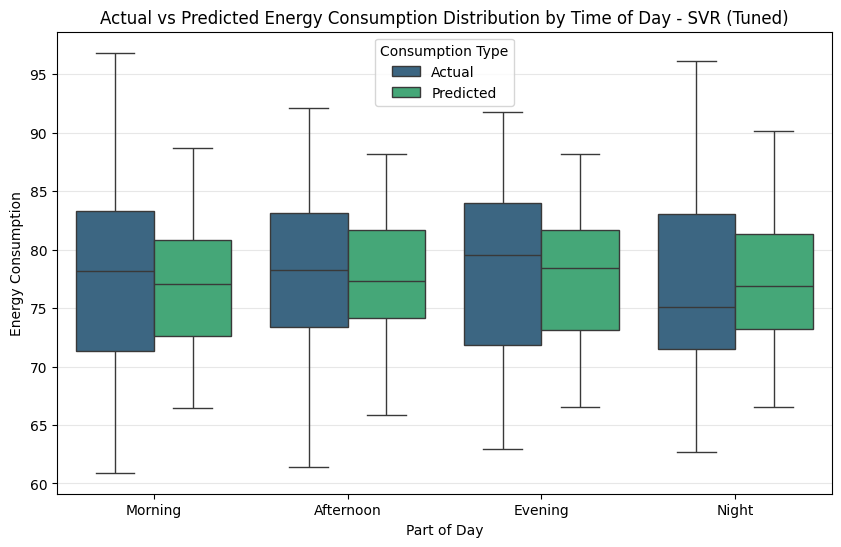

In [ ]:
# ==== Combined Boxplot by Part of Day (Actual vs Predicted) ====

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure best_svr_test_frame is available from previous cells
if 'best_svr_test_frame' in locals():
    analysis_df_svr = best_svr_test_frame.copy()
    analysis_df_svr['Day Type'] = analysis_df_svr['Weekend'].map({0: 'Weekday', 1: 'Weekend'}) # Keep Day Type for consistency with analysis_df_svr

    # Combine actual and predicted into a single DataFrame for plotting boxplots
    # Create a long-form DataFrame suitable for seaborn boxplot
    boxplot_data = analysis_df_svr.melt(id_vars=['Timestamp', 'DayOfWeek', 'Weekend', 'PartOfDay', 'Day Type'],
                                          value_vars=['Actual', 'Predicted'],
                                          var_name='Type', value_name='EnergyConsumption')


    # Set proper order for parts of day
    partofday_order = ['Morning', 'Afternoon', 'Evening', 'Night']
    boxplot_data['PartOfDay'] = pd.Categorical(boxplot_data['PartOfDay'], categories=partofday_order, ordered=True)
    boxplot_data = boxplot_data.sort_values(['PartOfDay', 'Type'])

    plt.figure(figsize=(10, 6))
    sns.boxplot(data=boxplot_data, x='PartOfDay', y='EnergyConsumption', hue='Type', palette='viridis')
    plt.xlabel('Part of Day')
    plt.ylabel('Energy Consumption')
    plt.title(f'Actual vs Predicted Energy Consumption Distribution by Time of Day - {best_model_name_final}')
    plt.legend(title='Consumption Type')
    plt.grid(axis='y', alpha=0.3)
    plt.show()

else:
    print("Best SVR test frame not available for combined boxplot.")

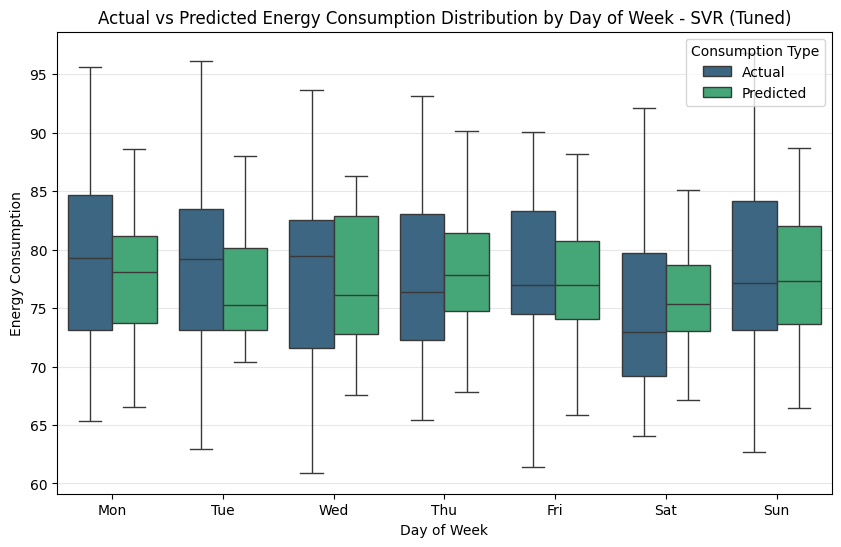

In [ ]:
# ==== Combined Boxplot by Day of Week (Actual vs Predicted) ====

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure best_svr_test_frame is available from previous cells
if 'best_svr_test_frame' in locals():
    analysis_df_svr = best_svr_test_frame.copy()

    # Combine actual and predicted into a single DataFrame for plotting boxplots
    # Create a long-form DataFrame suitable for seaborn boxplot
    # Removed 'Day Type' from id_vars as it's not present in analysis_df_svr at this point
    boxplot_data_dow = analysis_df_svr.melt(id_vars=['Timestamp', 'DayOfWeek', 'Weekend', 'PartOfDay'],
                                          value_vars=['Actual', 'Predicted'],
                                          var_name='Type', value_name='EnergyConsumption')

    # Set proper order for days of week
    dayofweek_order = [0, 1, 2, 3, 4, 5, 6] # Mon=0, Tue=1, ..., Sun=6
    day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'] # For labeling the x-axis if needed
    boxplot_data_dow['DayOfWeek'] = pd.Categorical(boxplot_data_dow['DayOfWeek'], categories=dayofweek_order, ordered=True)
    boxplot_data_dow = boxplot_data_dow.sort_values(['DayOfWeek', 'Type'])


    plt.figure(figsize=(10, 6))
    sns.boxplot(data=boxplot_data_dow, x='DayOfWeek', y='EnergyConsumption', hue='Type', palette='viridis')
    plt.xticks(range(7), day_labels) # Set x-axis labels to day names
    plt.xlabel('Day of Week')
    plt.ylabel('Energy Consumption')
    plt.title(f'Actual vs Predicted Energy Consumption Distribution by Day of Week - {best_model_name_final}')
    plt.legend(title='Consumption Type')
    plt.grid(axis='y', alpha=0.3)
    plt.show()

else:
    print("Best SVR test frame not available for combined boxplot.")

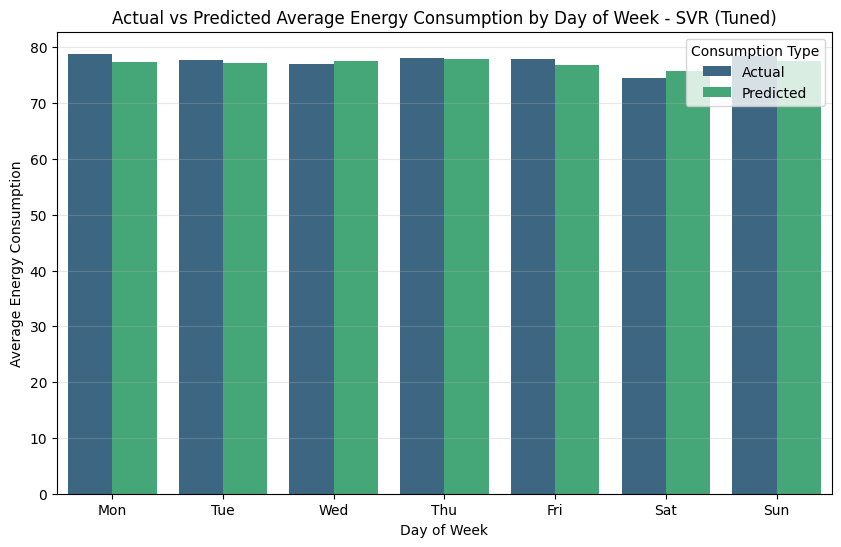

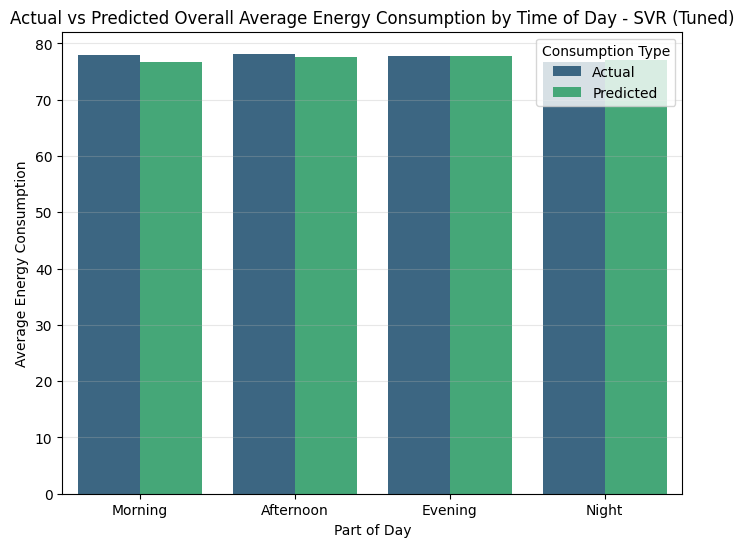

In [ ]:
# ==== Combined Bar Charts for Best Model (SVR) ====

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure best_svr_test_frame is available from previous cells
if 'best_svr_test_frame' in locals():
    analysis_df_svr = best_svr_test_frame.copy()
    analysis_df_svr['Day Type'] = analysis_df_svr['Weekend'].map({0: 'Weekday', 1: 'Weekend'})

    # --- Combined Bar Chart by Day of Week ---
    # Calculate average actual and predicted consumption by Day of Week
    avg_actual_dow = analysis_df_svr.groupby('DayOfWeek')['Actual'].mean()
    avg_pred_dow = analysis_df_svr.groupby('DayOfWeek')['Predicted'].mean()

    # Create a combined DataFrame for plotting
    combined_dow_df = pd.DataFrame({
        'DayOfWeek': range(7),
        'Actual': avg_actual_dow,
        'Predicted': avg_pred_dow
    }).melt(id_vars='DayOfWeek', var_name='Type', value_name='EnergyConsumption')

    day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

    plt.figure(figsize=(10, 6))
    sns.barplot(data=combined_dow_df, x='DayOfWeek', y='EnergyConsumption', hue='Type', palette='viridis')
    plt.xticks(range(7), day_labels)
    plt.xlabel('Day of Week')
    plt.ylabel('Average Energy Consumption')
    plt.title(f'Actual vs Predicted Average Energy Consumption by Day of Week - {best_model_name_final}')
    plt.legend(title='Consumption Type')
    plt.grid(axis='y', alpha=0.3)
    plt.show()

    # --- Combined Bar Chart by Part of Day (Actual vs Predicted) ---
    # Calculate overall average actual and predicted energy consumption by Part of Day
    overall_avg_actual_pod = analysis_df_svr.groupby('PartOfDay')['Actual'].mean().reset_index()
    overall_avg_pred_pod = analysis_df_svr.groupby('PartOfDay')['Predicted'].mean().reset_index()


    # Combine actual and predicted into a single DataFrame for plotting
    overall_avg_actual_pod['Type'] = 'Actual'
    overall_avg_pred_pod['Type'] = 'Predicted'

    # Rename the value columns to 'EnergyConsumption' before concatenating
    overall_avg_actual_pod = overall_avg_actual_pod.rename(columns={'Actual': 'EnergyConsumption'})
    overall_avg_pred_pod = overall_avg_pred_pod.rename(columns={'Predicted': 'EnergyConsumption'})

    combined_pod_overall_df = pd.concat([overall_avg_actual_pod, overall_avg_pred_pod])

    # Set proper order for parts of day
    partofday_order = ['Morning', 'Afternoon', 'Evening', 'Night']
    combined_pod_overall_df['PartOfDay'] = pd.Categorical(combined_pod_overall_df['PartOfDay'], categories=partofday_order, ordered=True)
    combined_pod_overall_df = combined_pod_overall_df.sort_values(['PartOfDay', 'Type'])

    plt.figure(figsize=(8, 6))
    sns.barplot(data=combined_pod_overall_df, x='PartOfDay', y='EnergyConsumption', hue='Type', palette='viridis')
    plt.xlabel('Part of Day')
    plt.ylabel('Average Energy Consumption')
    plt.title(f'Actual vs Predicted Overall Average Energy Consumption by Time of Day - {best_model_name_final}')
    plt.legend(title='Consumption Type')
    plt.grid(axis='y', alpha=0.3)
    plt.show()


else:
    print("Best SVR test frame not available for combined bar charts.")

## **Conclusion**

This notebook explored predicting energy consumption using various machine learning and time series models. The process involved:

1.  **Data Loading and Initial Review:** We started by loading the `Energy_consumption.csv` dataset and performed an initial review to understand its structure, data types, and summary statistics.
2.  **Data Review & Cleaning:** We confirmed the dataset's shape, checked for missing values and duplicates (finding none in this case), and examined the distribution and potential outliers of key features.
3.  **Exploratory Data Analysis (EDA) and Visualization:** Through correlation matrices, scatter plots, histograms, and boxplots, we gained insights into the relationships between features and energy consumption. Notably, Temperature showed the strongest linear correlation. Visualizations of average consumption by Day of Week also revealed potential weekly patterns.
4.  **Encoding:** Categorical variables like HVACUsage, LightingUsage, DayOfWeek, and Holiday were converted into a numerical format using Label Encoding to be suitable for machine learning models.
5.  **Feature Engineering:** New features were created from the Timestamp column (Hour, Month, Weekend, PartOfDay) and existing features (EnergyPerOccupant, lagged energy consumption, and rolling means) to capture temporal patterns and relationships.
6.  **Normalization / Scaling:** Numerical features were scaled using StandardScaler to ensure they were on a similar scale, which is important for many machine learning algorithms.
7.  **Modeling & Training:** We trained a baseline Linear Regression model and several advanced models (Random Forest, Gradient Boosting, SVR, ARIMA, SARIMA, SARIMAX) on a chronological train-test split of the data.
8.  **Hyperparameter Tuning:** We performed hyperparameter tuning for most models to optimize their performance. This process significantly improved the R² for several models, particularly SVR and Gradient Boosting.
9.  **Model Evaluation and Selection:** The models were evaluated using R², RMSE, and MAE on the test set. The Tuned SVR model achieved the highest R² (52.51%), making it the best performing model in this analysis.
10. **Detailed Analysis of the Best Model:** We visualized the performance of the best model (Tuned SVR) over time, examined the distribution of its residuals, and analyzed its ability to capture daily and weekly energy consumption patterns.

**Key Takeaways:**

*   Temperature is a primary driver of energy consumption in this dataset.
*   Temporal features (time of day, day of week, historical usage) are crucial for improving prediction accuracy.
*   Advanced models and hyperparameter tuning can lead to better performance compared to simpler models.
*   The Tuned SVR model provides the most accurate predictions based on the evaluated metrics.
*   The chosen models, especially the best one, are reasonably capable of capturing the general trends and patterns in energy consumption over time and across different periods of the day and week.

This analysis provides a solid foundation for understanding the factors influencing energy consumption and a tuned model for making predictions. Further work could involve exploring more advanced time series models, experimenting with different feature engineering techniques, or incorporating external data sources (e.g., weather forecasts) to potentially improve prediction accuracy.